<a id="bookmark-introduction"></a>

# 1. Introduction

## Project Title

**ExoRank: Scientific Prioritization of Kepler Exoplanet Candidates with Interpretable Machine Learning**

## Background

The Kepler Space Telescope observed the brightness of thousands of stars to detect possible exoplanets. When a planet passes in front of its host star, it can cause a small periodic decrease in the observed brightness. This event is called a **transit**.

However, not every transit-like signal is caused by a real planet. Some signals are produced by eclipsing binary stars, background objects, stellar variability, or instrumental noise. Therefore, many detected objects need to be carefully classified before they can be considered reliable planet discoveries.

In the Kepler dataset, each object is called a **Kepler Object of Interest**, or **KOI**. Each KOI has a final disposition label such as **CONFIRMED**, **FALSE POSITIVE**, or **CANDIDATE**.

## Problem

Astronomers may have thousands of possible planet-like signals. It is not practical to manually study every object with the same priority. Machine learning can help by learning patterns from already classified objects and then using those patterns to prioritize unresolved candidates.

## Project Objective

The objective of this project is to build a leakage-free machine learning model that learns to distinguish **CONFIRMED exoplanets** from **FALSE POSITIVES** using physically meaningful features. After training and evaluating several models, the best model will be used to assign a planet-like probability to unresolved **CANDIDATE** objects.

The final goal is not only classification, but also **scientific prioritization**: ranking Kepler candidates that may deserve further observation or investigation.

## Machine Learning Task

This project has two connected tasks:

1. **Binary classification**
   Predict whether a labelled KOI is a confirmed planet or a false positive.

2. **Candidate prioritization**
   Apply the trained model to unresolved candidate objects and rank them by predicted planet probability.

## Why This Project Matters

This project is scientifically interesting because false positives are a serious challenge in exoplanet discovery. A model that can separate likely planets from false positives may help researchers focus attention on the most promising candidates. It is also a good machine learning problem because it combines data cleaning, exploratory analysis, leakage prevention, model comparison, interpretation, and ranking.


# 🔖 Project Bookmarks / Quick Navigation

Use these links to jump between the main parts of the notebook:

1. [Introduction](#bookmark-introduction)
2. [Feature dictionary](#bookmark-feature-dictionary)
3. [Feature relationships and correlation](#bookmark-feature-relationships)
4. [Train/test split](#bookmark-train-test)
5. [Model training](#bookmark-model-training)
6. [Model comparison](#bookmark-model-comparison)
7. [Cross-validation](#bookmark-cross-validation)
8. [Hyperparameter tuning](#bookmark-hyperparameter-tuning)
9. [Final model selection](#bookmark-final-model-selection)
10. [Probability-based evaluation](#bookmark-probability-evaluation)
11. [Prediction vs true values](#bookmark-prediction-vs-true)
12. [Model interpretation](#bookmark-model-interpretation)
13. [Candidate prioritization](#bookmark-candidate-prioritization)
14. [Unsupervised similarity check](#bookmark-unsupervised-similarity)
15. [Reference planet similarity check](#bookmark-reference-planet-similarity)
16. [Consensus candidates: priority + reference similarity](#bookmark-consensus-candidates)
17. [Scientific priority score](#bookmark-scientific-priority-score)
18. [Ranking stability](#bookmark-ranking-stability)
19. [Final results and findings](#bookmark-final-results)
20. [Future work](#bookmark-future-work)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


<a id="bookmark-feature-dictionary"></a>

# Feature Dictionary

In this project, I use selected physical, transit-related, and stellar features from the Kepler Objects of Interest dataset.

| Feature         | Meaning                                | Why it matters                                                                              |
| --------------- | -------------------------------------- | ------------------------------------------------------------------------------------------- |
| `koi_period`    | Orbital period in days                 | Shows how often the transit repeats. Real planets usually produce periodic transit signals. |
| `koi_time0bk`   | Transit epoch                          | Represents the timing of the first detected transit.                                        |
| `koi_impact`    | Impact parameter                       | Describes the transit geometry and how centrally the object passes in front of the star.    |
| `koi_duration`  | Transit duration in hours              | Measures how long the transit lasts. It helps describe the transit shape.                   |
| `koi_depth`     | Transit depth in parts per million     | Measures how much stellar brightness is blocked during transit.                             |
| `koi_prad`      | Estimated planet radius in Earth radii | Important because very large radius values may be less planet-like and more suspicious.     |
| `koi_teq`       | Equilibrium temperature in Kelvin      | Approximate planet temperature based on stellar radiation assumptions.                      |
| `koi_insol`     | Insolation flux relative to Earth      | Measures how much stellar energy the object receives compared with Earth.                   |
| `koi_model_snr` | Transit signal-to-noise ratio          | Higher values indicate a stronger and clearer transit signal.                               |
| `koi_steff`     | Stellar effective temperature          | Describes the temperature of the host star.                                                 |
| `koi_slogg`     | Stellar surface gravity                | Helps describe the type and evolutionary state of the host star.                            |
| `koi_srad`      | Stellar radius in solar radii          | Important because planet radius estimates depend on the host star radius.                   |
| `koi_kepmag`    | Kepler magnitude                       | Describes the brightness of the observed target star.                                       |

I intentionally exclude leakage-related columns such as `koi_score`, `koi_pdisposition`, and the false-positive flag columns because they are too close to the final disposition label.


In [2]:

url = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&format=csv"
df = pd.read_csv(url)

df.head()

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra_str,dec_str,koi_kepmag,koi_kepmag_err
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,4.467,0.064,-0.096,0.927,0.105,-0.061,19h27m44.22s,+48d08m29.9s,15.347,NaN
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,4.467,0.064,-0.096,0.927,0.105,-0.061,19h27m44.22s,+48d08m29.9s,15.347,NaN
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,4.544,0.044,-0.176,0.868,0.233,-0.078,19h48m01.16s,+48d08m02.9s,15.436,NaN
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,4.564,0.053,-0.168,0.791,0.201,-0.067,19h02m08.31s,+48d17m06.8s,15.597,NaN
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,4.438,0.070,-0.210,1.046,0.334,-0.133,19h15m01.17s,+48d13m34.3s,15.509,NaN


In [3]:
df.shape

(9564, 50)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              9564 non-null   int64  
 1   kepoi_name         9564 non-null   object 
 2   kepler_name        2747 non-null   object 
 3   koi_disposition    9564 non-null   object 
 4   koi_pdisposition   9564 non-null   object 
 5   koi_score          8054 non-null   float64
 6   koi_fpflag_nt      9564 non-null   int64  
 7   koi_fpflag_ss      9564 non-null   int64  
 8   koi_fpflag_co      9564 non-null   int64  
 9   koi_fpflag_ec      9564 non-null   int64  
 10  koi_period         9564 non-null   float64
 11  koi_period_err1    9110 non-null   float64
 12  koi_period_err2    9110 non-null   float64
 13  koi_time0bk        9564 non-null   float64
 14  koi_time0bk_err1   9110 non-null   float64
 15  koi_time0bk_err2   9110 non-null   float64
 16  koi_impact         9201 

In [5]:
df.select_dtypes(include=['object']).nunique()

,0
kepoi_name,9564
kepler_name,2747
koi_disposition,3
koi_pdisposition,2
koi_tce_delivname,3
ra_str,8103
dec_str,8144


In [6]:
df['koi_disposition'].value_counts()

,count
koi_disposition,
FALSE POSITIVE,4839
CONFIRMED,2747
CANDIDATE,1978


In [7]:
df['koi_pdisposition'].value_counts()

,count
koi_pdisposition,
FALSE POSITIVE,4847
CANDIDATE,4717


In [8]:
df['koi_tce_delivname'].value_counts()

,count
koi_tce_delivname,
q1_q17_dr25_tce,8054
q1_q16_tce,796
q1_q17_dr24_tce,368


In [9]:
df.duplicated().sum()

np.int64(0)

I focused on physically meaningful numerical features, removed constant columns, excluded leakage-related columns, and handled missing values inside model pipelines using median imputation.

In [10]:
df.columns.duplicated().sum()

np.int64(0)

In [11]:
# Drop Columns  with Nan value
missing_cols = ['koi_teq_err1', 'koi_teq_err2', 'koi_kepmag_err']
df = df.drop(columns=missing_cols, errors='ignore')


In [12]:
model_df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

In [13]:
candidate_df = df[df['koi_disposition']=='CANDIDATE'].copy()

In [14]:
print("Training data shape:", model_df.shape)
print("Candidate data shape:", candidate_df.shape)

Training data shape: (7586, 47)
Candidate data shape: (1978, 47)


Before training the model, I compared the physical distributions of confirmed planets and false positives. Some features, such as planet radius, impact parameter, signal-to-noise ratio, and transit duration, already show meaningful differences between the two groups.

/tmp/ipykernel_7616/3463973373.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='koi_disposition', order=df['koi_disposition'].value_counts().index, palette='pastel')


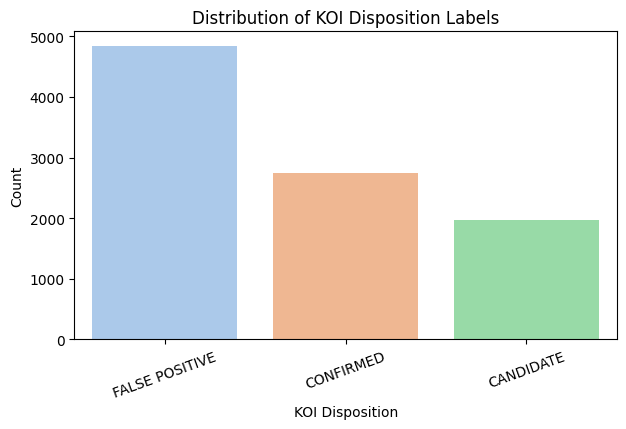

In [15]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='koi_disposition', order=df['koi_disposition'].value_counts().index, palette='pastel')
plt.title('Distribution of KOI Disposition Labels')
plt.xlabel('KOI Disposition')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

In [16]:
#Deselecting Features
Drop_features = [
    #target
    'koi_disposition',

    #ID/names
    'kepid',
    'kepoi_name',
    'kepler_name',

    #text/high cardinality string columns
    'ra_str',
    'dec_str',
    'koi_tce_delivname',

    #Leakage columns
    'koi_pdisposition',
    'koi_score',

    #false-positive flags: close to the answer
    'koi_fpflag_nt',
    'koi_fpflag_ss',
    'koi_fpflag_co',
    'koi_fpflag_ec',

    #not needed for first clean version
    'koi_tce_plnt_num'
]

In [17]:
#selecting features

feature_cols = [
    'koi_period',
    'koi_time0bk',
    'koi_impact',
    'koi_duration',
    'koi_depth',
    'koi_prad',
    'koi_teq',
    'koi_insol',
    'koi_model_snr',
    'koi_steff',
    'koi_slogg',
    'koi_srad',
    'koi_kepmag'
]

/tmp/ipykernel_7616/1446590721.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='rocket')


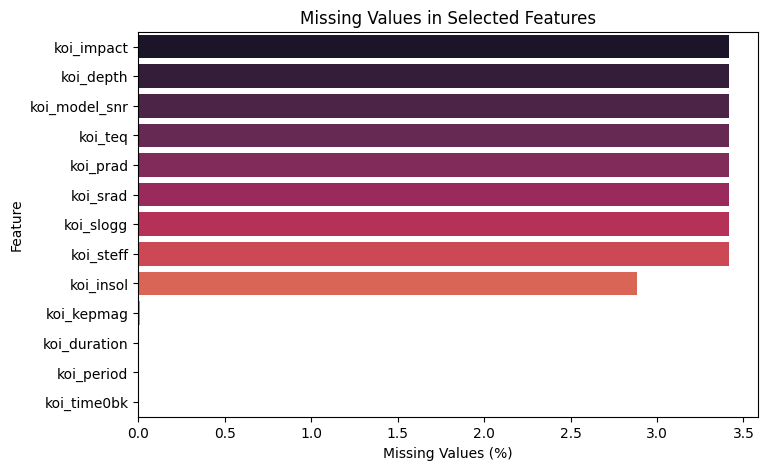

In [18]:
missing_percent = model_df[feature_cols].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='rocket')
plt.title('Missing Values in Selected Features')
plt.xlabel('Missing Values (%)')
plt.ylabel('Feature')
plt.show()

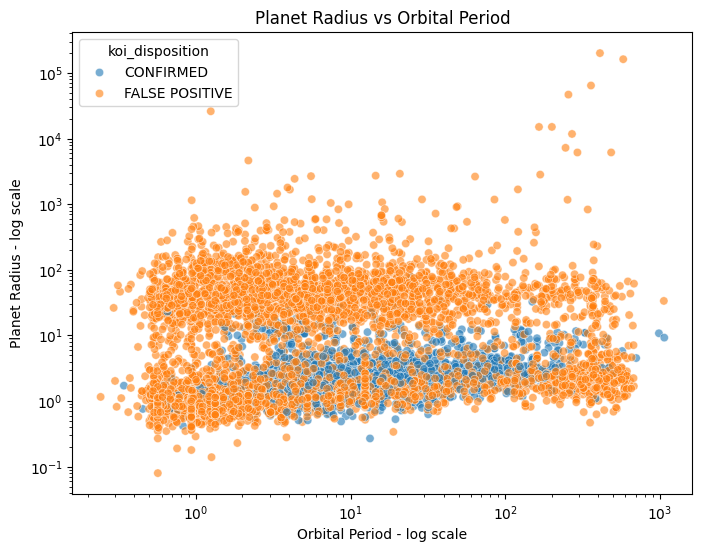

In [19]:
#Radius vs period
plot_df = model_df[
    (model_df['koi_prad'] > 0) &
    (model_df['koi_period'] > 0)
].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='koi_period', y='koi_prad', hue='koi_disposition', alpha=0.6)

plt.xscale('log')
plt.yscale('log')
plt.title('Planet Radius vs Orbital Period')
plt.xlabel('Orbital Period - log scale')
plt.ylabel('Planet Radius - log scale')
plt.show()

Planet radius is especially important because very large planet-radius estimates can sometimes indicate false positives, such as eclipsing binary stars or other non-planetary signals. Therefore, visualizing the radius distribution helps explain why this feature becomes important for the model.

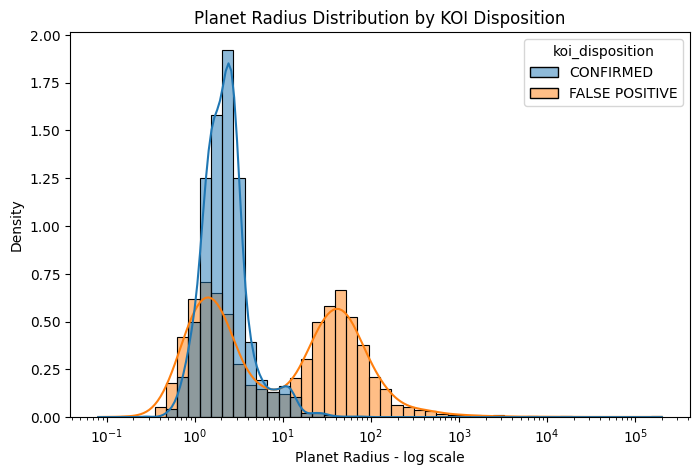

In [20]:
#Distribution of planet radius by disposition

radius_plot_df = model_df[(model_df['koi_prad'] > 0) & (model_df['koi_prad'].notna())].copy()

plt.figure(figsize=(8, 5))
sns.histplot(data=radius_plot_df, x='koi_prad', hue='koi_disposition', bins=50, kde=True, stat='density', common_norm=False, log_scale=True, alpha=0.5)

plt.title('Planet Radius Distribution by KOI Disposition')
plt.xlabel('Planet Radius - log scale')
plt.ylabel('Density')
plt.show()

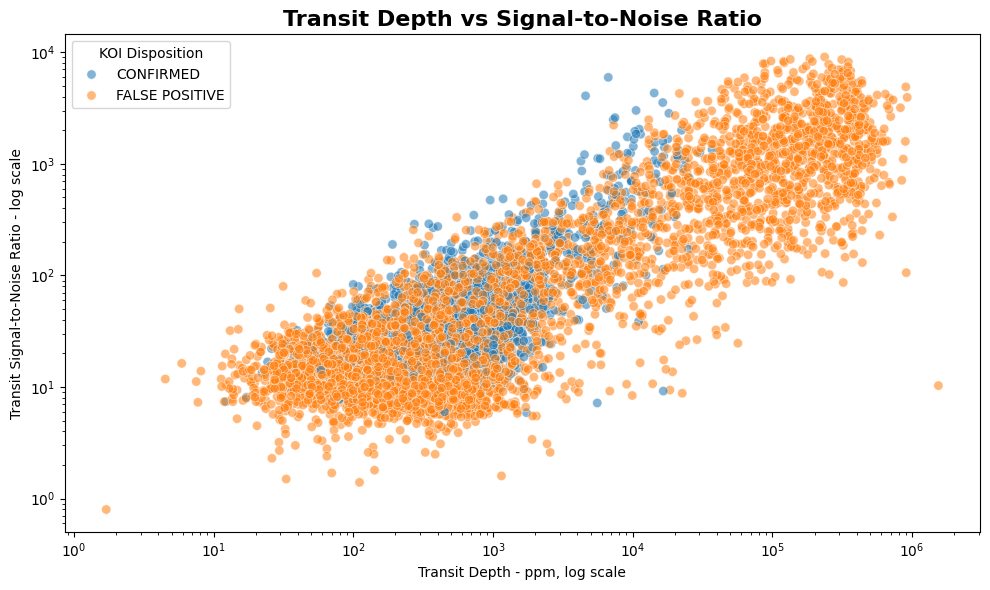

In [21]:
#EDA Scatter Plot: Transit Depth vs Signal-to-Noise Ratio

import os

#Use only known labels for EDA comparison
eda_signal_df = model_df[
    (model_df['koi_depth'] > 0) &
    (model_df['koi_model_snr'] > 0) &
    (model_df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE']))
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(data=eda_signal_df, x='koi_depth', y='koi_model_snr', hue='koi_disposition', alpha=0.55, s=45)

plt.xscale('log')
plt.yscale('log')

plt.title('Transit Depth vs Signal-to-Noise Ratio', fontsize=16, weight='bold')
plt.xlabel('Transit Depth - ppm, log scale')
plt.ylabel('Transit Signal-to-Noise Ratio - log scale')
plt.legend(title='KOI Disposition')

plt.tight_layout()

# Save for presentation
os.makedirs("presentation_figures", exist_ok=True)
plt.savefig(
    "presentation_figures/transit_depth_vs_snr_by_disposition.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
eda_signal_df.groupby('koi_disposition')[['koi_depth', 'koi_model_snr']].median()

,koi_depth,koi_model_snr
koi_disposition,,
CONFIRMED,448.6,28.6
FALSE POSITIVE,576.0,34.3


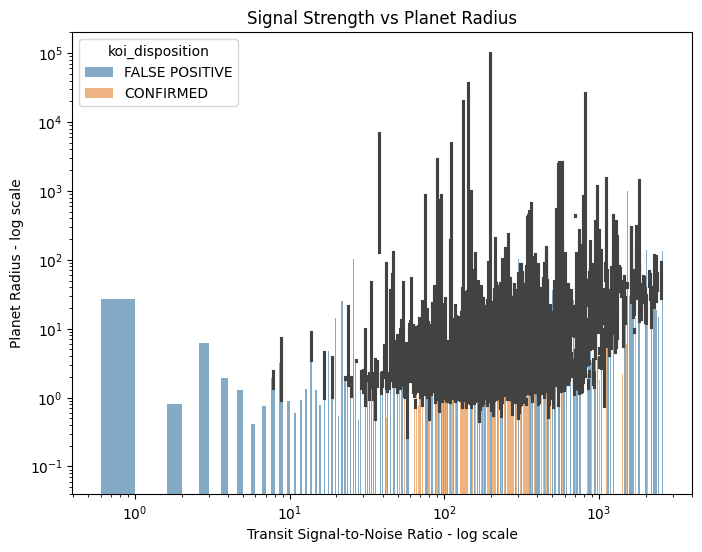

In [23]:
#SNR vs radius
plot_df = model_df[
    (model_df['koi_prad'] > 0) &
    (model_df['koi_model_snr'] > 0)
].copy()

plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df,x='koi_model_snr',y='koi_prad',hue='koi_disposition',alpha=0.6)

plt.xscale('log')
plt.yscale('log')
plt.title('Signal Strength vs Planet Radius')
plt.xlabel('Transit Signal-to-Noise Ratio - log scale')
plt.ylabel('Planet Radius - log scale')
plt.show()

/tmp/ipykernel_7616/323897566.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= model_df, x='koi_disposition', y=feature, ax=ax, palette='coolwarm')
/tmp/ipykernel_7616/323897566.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= model_df, x='koi_disposition', y=feature, ax=ax, palette='coolwarm')
/tmp/ipykernel_7616/323897566.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= model_df, x='koi_disposition', y=feature, ax=ax, palette='coolwarm')


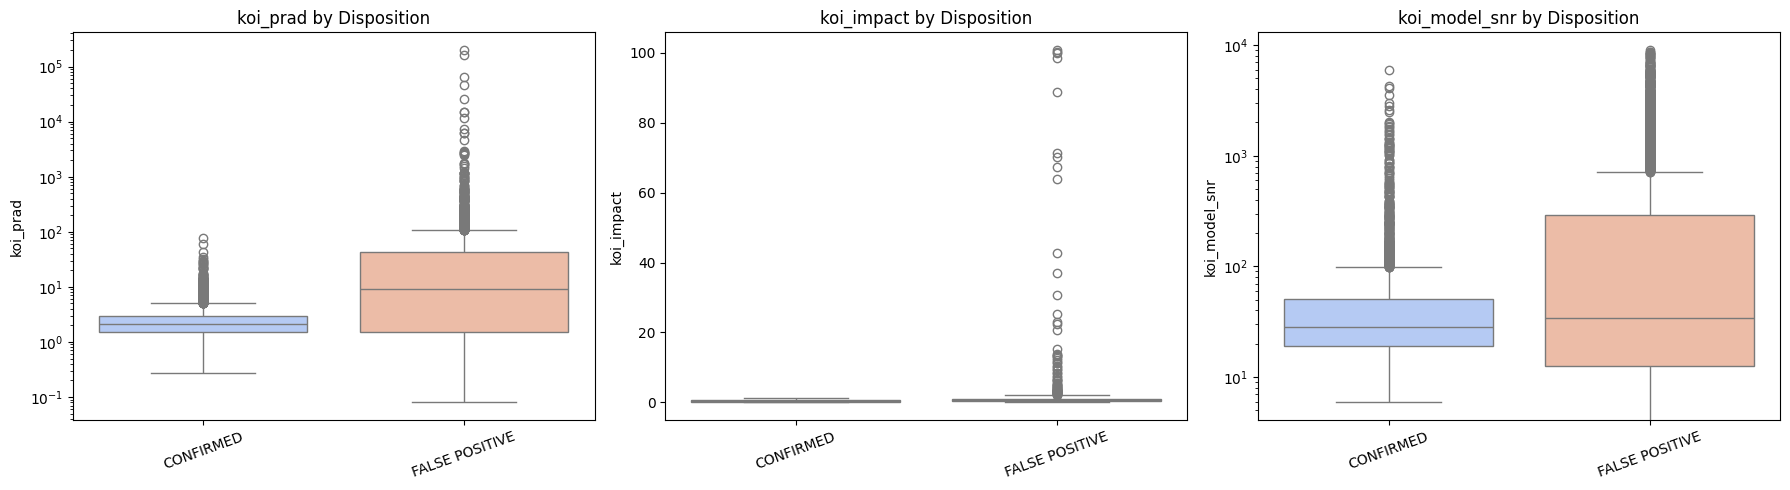

In [24]:
#Boxplots for the most important scientific features

important_features = ['koi_prad', 'koi_impact', 'koi_model_snr']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, important_features):
    sns.boxplot(data= model_df, x='koi_disposition', y=feature, ax=ax, palette='coolwarm')

    ax.set_title(f'{feature} by Disposition')
    ax.set_xlabel('')
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=20)

    if feature in ['koi_prad', 'koi_model_snr']:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

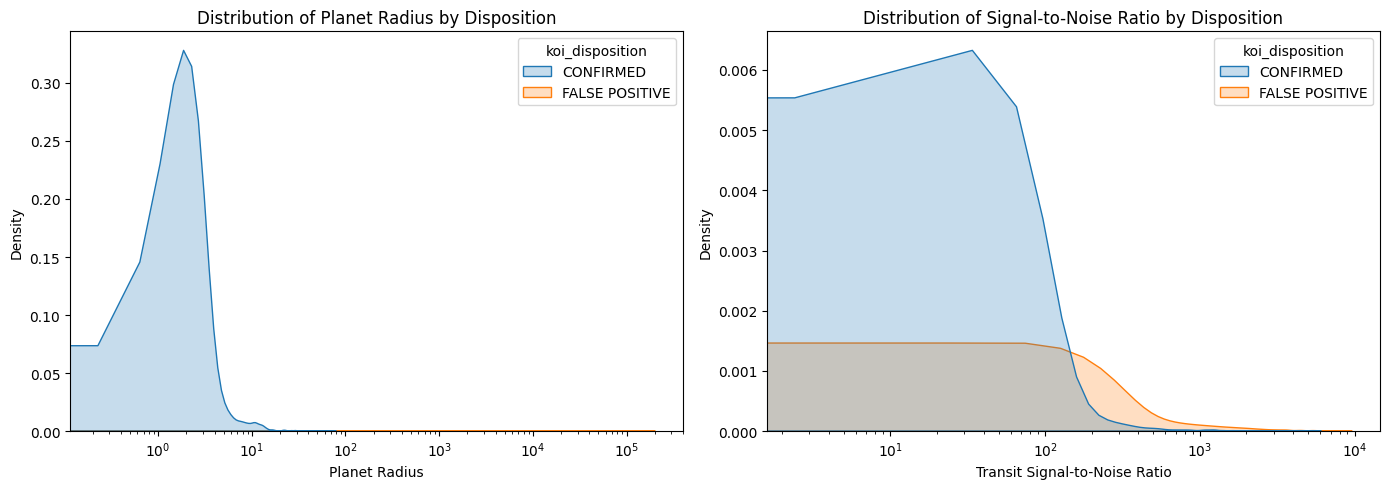

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    data=model_df,
    x='koi_prad',
    hue='koi_disposition',
    fill=True,
    common_norm=False,
    alpha=0.25,
    ax=axes[0]
)

axes[0].set_title('Distribution of Planet Radius by Disposition')
axes[0].set_xlabel('Planet Radius')
axes[0].set_ylabel('Density')
axes[0].set_xscale('log')

sns.kdeplot(
    data=model_df,
    x='koi_model_snr',
    hue='koi_disposition',
    fill=True,
    common_norm=False,
    alpha=0.25,
    ax=axes[1]
)

axes[1].set_title('Distribution of Signal-to-Noise Ratio by Disposition')
axes[1].set_xlabel('Transit Signal-to-Noise Ratio')
axes[1].set_ylabel('Density')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

<a id="bookmark-feature-relationships"></a>

## Feature Relationships

Before training the models, I also checked correlations between selected numerical features. This is important because some physical features may carry overlapping information. For example, planet radius, transit depth, stellar radius, and signal-to-noise ratio may be related.

This helps explain why different feature-importance methods may not always produce exactly the same ranking.

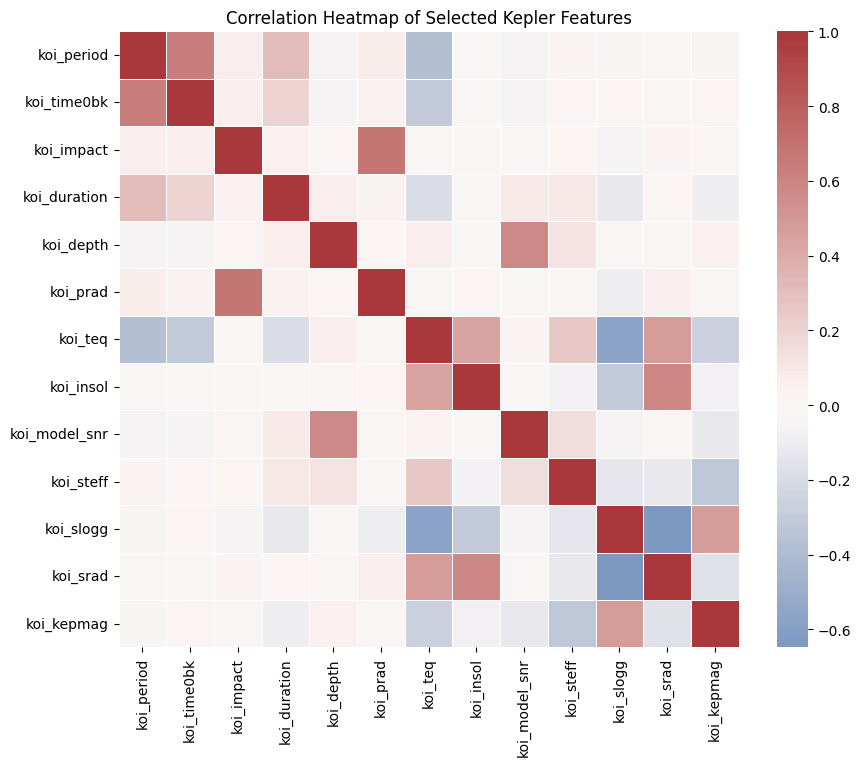

In [26]:
#Correlation heatmap of selected numerical features

corr_matrix = model_df[feature_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='vlag', center=0, linewidths=0.5)

plt.title('Correlation Heatmap of Selected Kepler Features')
plt.show()

<a id="bookmark-train-test"></a>

## Feature Matrix and Train/Test Split

In this step, I define the input features `X` and the target label `y`.

The target is binary:

- `CONFIRMED` = 1
- `FALSE POSITIVE` = 0

I split the data before imputation and scaling. This is important because preprocessing should be learned only from the training set, not from the test set. This helps avoid data leakage.


In [27]:
#Define Features and target

X = model_df[feature_cols]
y = model_df['koi_disposition'].map({
    'CONFIRMED': 1,
    'FALSE POSITIVE': 0
})

In [28]:
#Split data before imputation/scaling

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<a id="bookmark-model-training"></a>

# Model Training: From Baseline to Nonlinear Models

In this section, I train several machine-learning models to distinguish confirmed exoplanets from false positives.

I start with Logistic Regression as a simple baseline model. Then I test more flexible models such as Random Forest, Gradient Boosting, and Support Vector Machine. This makes the project more reliable because the final result is not based on only one model.

The goal is not only to get high accuracy, but to find a model that is accurate, stable, interpretable, and useful for ranking unresolved Kepler candidates.

## Model Training Experiments

### 1. Logistic Regression — baseline model

In [29]:
log_reg_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_logreg = log_reg_pipeline.predict(X_test)
y_proba_logreg = log_reg_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85       968
           1       0.70      0.91      0.79       550

    accuracy                           0.83      1518
   macro avg       0.82      0.85      0.82      1518
weighted avg       0.85      0.83      0.83      1518



### 2. Random Forest — nonlinear tree-based model

In [30]:

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       968
           1       0.91      0.91      0.91       550

    accuracy                           0.93      1518
   macro avg       0.93      0.93      0.93      1518
weighted avg       0.93      0.93      0.93      1518



### 3. Gradient Boosting — boosted tree model

In [31]:

from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       968
           1       0.89      0.91      0.90       550

    accuracy                           0.93      1518
   macro avg       0.92      0.92      0.92      1518
weighted avg       0.93      0.93      0.93      1518



### 4. Support Vector Machine — margin-based nonlinear model

In [32]:

from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42 ))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87       968
           1       0.72      0.93      0.81       550

    accuracy                           0.85      1518
   macro avg       0.84      0.86      0.84      1518
weighted avg       0.87      0.85      0.85      1518



<a id="bookmark-model-comparison"></a>

## Model Performance Comparison

After training the models, I compare them using accuracy, macro precision, macro recall, macro F1-score, and ROC-AUC.

For this project, macro F1-score and ROC-AUC are especially important. Macro F1-score calculates the F1-score for both classes and averages them equally, so it is better for an imbalanced dataset. ROC-AUC helps evaluate the model's ability to separate confirmed planets from false positives across thresholds.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

models = {
    'Logistic Regression': (y_pred_logreg, y_proba_logreg),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'Gradient Boosting': (y_pred_gb, y_proba_gb),
    'SVM': (y_pred_svm, y_proba_svm)
}

for name, (pred, proba) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision Macro': precision_score(y_test, pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, pred, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_test, pred, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Macro', ascending=False)
results_df


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC_AUC
1,Random Forest,0.934124,0.928172,0.929504,0.928830,0.978366
2,Gradient Boosting,0.926219,0.919153,0.921736,0.920413,0.975637
3,SVM,0.846509,0.838426,0.864339,0.841759,0.930782
0,Logistic Regression,0.828063,0.821161,0.846343,0.823151,0.903341


<a id="bookmark-cross-validation"></a>

# Cross-Validation

The previous model comparison was based on one train/test split. To make the evaluation more reliable, I also use 5-fold cross-validation. This helps check whether the model performance is stable across different data splits.

In [34]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']

pipelines = {
    'Logistic Regression': log_reg_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline,
    'SVM': svm_pipeline
}

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring)

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision Macro': scores['test_precision_macro'].mean(),
        'Recall Macro': scores['test_recall_macro'].mean(),
        'F1 Macro': scores['test_f1_macro'].mean(),
        'ROC_AUC': scores['test_roc_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='F1 Macro', ascending=False)

cv_results_df


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC_AUC
1,Random Forest,0.899431,0.906596,0.891863,0.890908,0.971526
2,Gradient Boosting,0.897588,0.903767,0.894276,0.890223,0.969071
3,SVM,0.815993,0.819736,0.837177,0.811327,0.913775
0,Logistic Regression,0.799905,0.802393,0.821340,0.795076,0.891666


<a id="bookmark-hyperparameter-tuning"></a>

# Hyperparameter Tuning

After comparing the models, I tune the Random Forest model because it is interpretable, works well with non-linear patterns, and provides feature importance. I use RandomizedSearchCV to test different combinations of Random Forest parameters.

In [35]:
#Hyperparameter tuning for Random Forest

from sklearn.model_selection import RandomizedSearchCV

rf_tuning_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(rf_tuning_pipeline, param_distributions=param_grid, n_iter=15, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("Best CV Macro F1 score:")
print(rf_search.best_score_)


Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Best CV Macro F1 score:
0.9088669979624612


In [36]:
#Evaluate tuned Random Forest on the test set

best_rf_pipeline = rf_search.best_estimator_

y_pred_best_rf = best_rf_pipeline.predict(X_test)
y_proba_best_rf = best_rf_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_best_rf))
print('ROc-AUC:', roc_auc_score(y_test, y_proba_best_rf))


              precision    recall  f1-score   support

           0       0.95      0.94      0.95       968
           1       0.90      0.91      0.91       550

    accuracy                           0.93      1518
   macro avg       0.92      0.93      0.93      1518
weighted avg       0.93      0.93      0.93      1518

ROc-AUC: 0.9775507137490608


In [37]:
#Add tuned Random Forest to model comparison

tuned_rf_result = pd.DataFrame([{
    'Model': 'Tuned Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_best_rf),
    'Precision Macro': precision_score(y_test, y_pred_best_rf, average='macro', zero_division=0),
    'Recall Macro': recall_score(y_test, y_pred_best_rf, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, y_pred_best_rf, average='macro'),
    'ROC_AUC': roc_auc_score(y_test, y_proba_best_rf)
}])

final_results_df = pd.concat([results_df, tuned_rf_result], ignore_index=True)
final_results_df = final_results_df.sort_values(by='F1 Macro', ascending=False)

final_results_df


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC_AUC
0,Random Forest,0.934124,0.928172,0.929504,0.928830,0.978366
4,Tuned Random Forest,0.930830,0.923990,0.926921,0.925416,0.977551
1,Gradient Boosting,0.926219,0.919153,0.921736,0.920413,0.975637
2,SVM,0.846509,0.838426,0.864339,0.841759,0.930782
3,Logistic Regression,0.828063,0.821161,0.846343,0.823151,0.903341


<a id="bookmark-final-model-selection"></a>

# Final Model Selection

The final model is selected based on the comparison table, especially macro F1-score and ROC-AUC.

Macro F1-score is important because the dataset is imbalanced. It gives equal importance to the `CONFIRMED` class and the `FALSE POSITIVE` class, instead of focusing mainly on the positive class. ROC-AUC is important because the next step of the project uses predicted probabilities to rank unresolved candidates.

Hyperparameter tuning was tested, but if the tuned Random Forest does not improve the score, the original Random Forest can still be selected as the final model. This is a useful scientific result: a more complex tuning step does not always produce a better model.


In [38]:
#Select final model automatically from the comparison table

model_objects = {
    'Logistic Regression': (log_reg_pipeline, y_pred_logreg, y_proba_logreg),
    'Random Forest': (rf_pipeline, y_pred_rf, y_proba_rf),
    'Gradient Boosting': (gb_pipeline, y_pred_gb, y_proba_gb),
    'SVM': (svm_pipeline, y_pred_svm, y_proba_svm),
    'Tuned Random Forest': (best_rf_pipeline, y_pred_best_rf, y_proba_best_rf)
}

best_model_name = final_results_df.sort_values(
    by=['F1 Macro', 'ROC_AUC'],
    ascending=False
).iloc[0]['Model']

best_pipeline, y_pred_best, y_proba_best = model_objects[best_model_name]

print("Final selected model:", best_model_name)
print(final_results_df[final_results_df['Model'] == best_model_name])


Final selected model: Random Forest
           Model  Accuracy  Precision Macro  Recall Macro  F1 Macro   ROC_AUC
0  Random Forest  0.934124         0.928172      0.929504   0.92883  0.978366


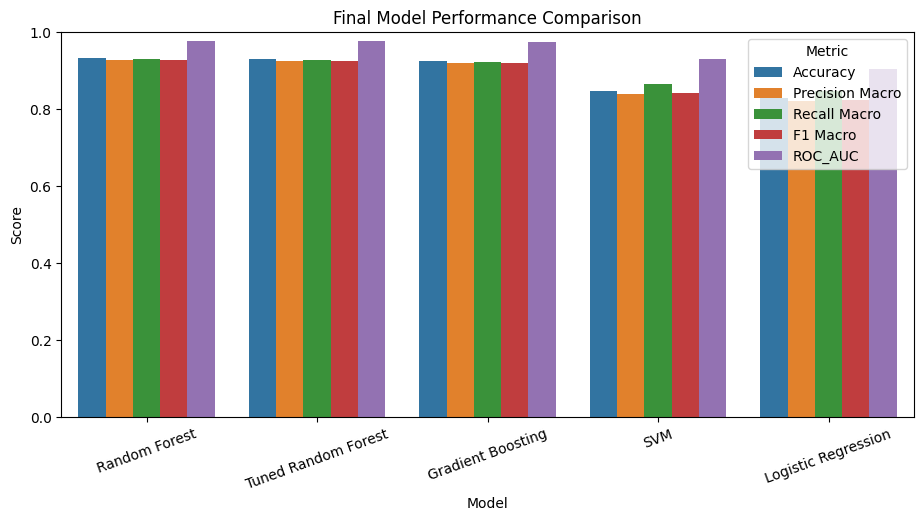

In [39]:
#Plot final model comparison

final_results_melted = final_results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro', 'ROC_AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=final_results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Final Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()


The final model should not be selected only by accuracy. Since the dataset is imbalanced and the goal is to separate confirmed planets from false positives, macro F1-score and ROC-AUC are more informative than accuracy alone.

After selecting the final model, I evaluate its probability behavior before applying it to unknown candidate objects.


/tmp/ipykernel_7616/459542910.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_model_metrics, x='Metric', y='Score', palette='bright')


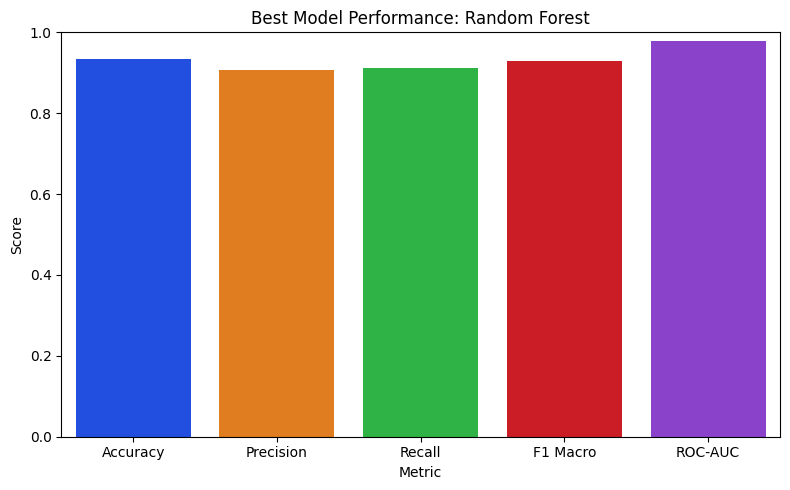

,Metric,Score
0,Accuracy,0.934124
1,Precision,0.906137
2,Recall,0.912727
3,F1 Macro,0.928830
4,ROC-AUC,0.978366


In [40]:
best_model_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Macro', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best, average='macro'),
        roc_auc_score(y_test, y_proba_best)
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(data=best_model_metrics, x='Metric', y='Score', palette='bright')

plt.title(f'Best Model Performance: {best_model_name}')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

best_model_metrics

This plot summarizes the performance of the selected best model on the test set.

Accuracy shows the overall percentage of correct predictions, but because the dataset is moderately imbalanced, F1 Macro is more important. F1 Macro gives equal importance to both CONFIRMED and FALSE POSITIVE classes.

ROC-AUC shows how well the model separates the two classes using predicted probabilities. This is especially useful for this project because candidate ranking is based on probability, not only on hard class labels.

<a id="bookmark-probability-evaluation"></a>

## Probability-Based Evaluation

Since the final goal is candidate ranking, I do not only evaluate hard class predictions. I also evaluate the predicted probabilities. ROC and Precision-Recall curves help show whether the model can separate confirmed planets from false positives across different probability thresholds.

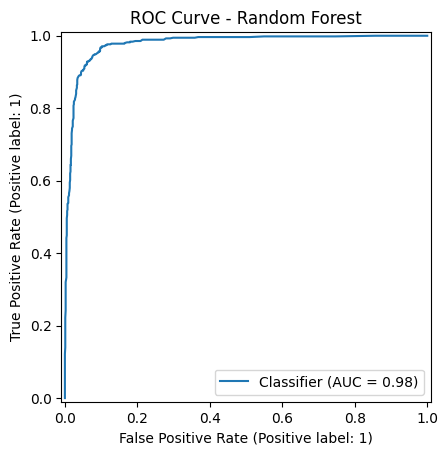

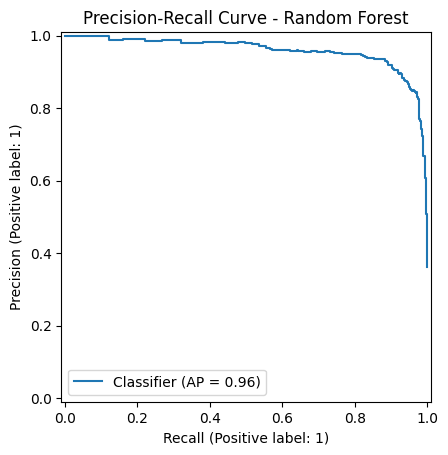

In [41]:
#ROC Curve and Precision-Recall Curve for the final model

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f'ROC Curve - {best_model_name}')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_best)
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.show()

## Probability Calibration

Because the model is used to rank unresolved candidates, the predicted probabilities should be interpreted carefully. A calibration curve checks whether predicted probabilities behave like real confidence levels.

If the curve is close to the diagonal line, the probabilities are better calibrated. If it is far from the diagonal line, the probabilities are still useful for ranking, but they should not be interpreted as exact astronomical confirmation probabilities.

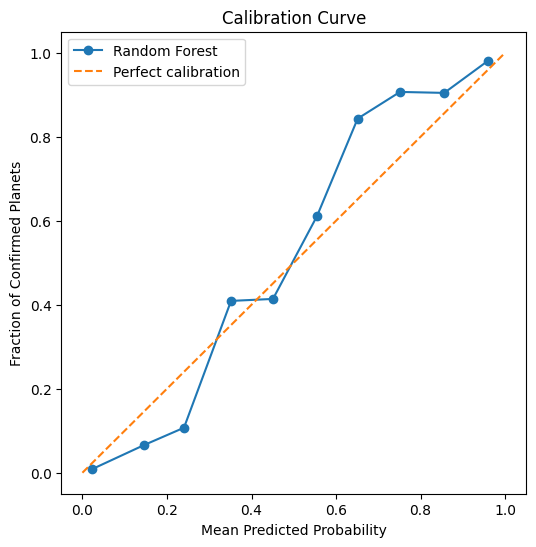

In [42]:
#Calibration curve for predicted probabilities

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10, strategy='uniform')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')

plt.title('Calibration Curve')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Confirmed Planets')
plt.legend()
plt.show()

<a id="bookmark-prediction-vs-true"></a>

# Prediction vs True Values

In this section, I compare the final model predictions with the true labels from the test set.

This is important because model performance should not only be summarized by one score. The confusion matrix shows which confirmed planets and false positives were correctly or incorrectly classified.

The probability distribution also helps show whether confirmed planets usually receive higher predicted probabilities than false positives.

For unresolved `CANDIDATE` objects, the true labels are unknown. Therefore, those objects are not used for accuracy calculation. They are used only for prioritization.

In [43]:
#Create prediction comparison dataframe

test_results_df = X_test.reset_index(drop=True).copy()

test_results_df['true_numeric'] = y_test.reset_index(drop=True)
test_results_df['predicted_numeric'] = y_pred_best
test_results_df['confirmed_probability'] = y_proba_best

label_map = {
    0: 'FALSE POSITIVE',
    1: 'CONFIRMED'
}

test_results_df['true_label'] = test_results_df['true_numeric'].map(label_map)
test_results_df['predicted_label'] = test_results_df['predicted_numeric'].map(label_map)

test_results_df['prediction_result'] = np.where(
    test_results_df['true_numeric'] == test_results_df['predicted_numeric'],
    'Correct',
    'Incorrect'
)

test_results_df.head()

,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag,true_numeric,predicted_numeric,confirmed_probability,true_label,predicted_label,prediction_result
0,25.953449,154.871600,0.6188,6.001,528.9,2.06,554.0,22.30,10.5,5591.0,4.559,0.860,15.790,0,0,0.406667,FALSE POSITIVE,FALSE POSITIVE,Correct
1,320.347208,406.230900,0.5480,7.159,262.8,1.58,274.0,1.33,8.8,6146.0,4.497,0.943,13.996,0,0,0.000000,FALSE POSITIVE,FALSE POSITIVE,Correct
2,1.368402,131.532033,NaN,4.580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.103,0,0,0.006667,FALSE POSITIVE,FALSE POSITIVE,Correct
3,11.748991,135.680450,0.1228,4.043,36.7,1.01,1114.0,363.51,12.5,6440.0,4.081,1.655,11.638,0,1,0.603333,FALSE POSITIVE,CONFIRMED,Incorrect
4,18.508453,131.545550,1.2580,6.596,758.9,29.33,683.0,51.32,30.1,5942.0,4.506,0.938,15.253,1,0,0.020000,CONFIRMED,FALSE POSITIVE,Incorrect


In [44]:
#True vs predicted label table

prediction_comparison_table = pd.crosstab(
    test_results_df['true_label'],
    test_results_df['predicted_label'], margins=True
)

prediction_comparison_table

predicted_label,CONFIRMED,FALSE POSITIVE,All
true_label,,,
CONFIRMED,502,48,550
FALSE POSITIVE,52,916,968
All,554,964,1518


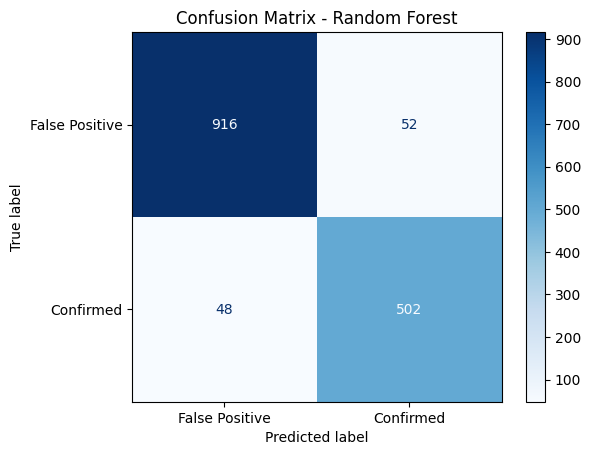

In [45]:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, display_labels=['False Positive', 'Confirmed'], cmap='Blues'
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

/tmp/ipykernel_7616/1323671735.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_results_df, x='prediction_result', palette='viridis')


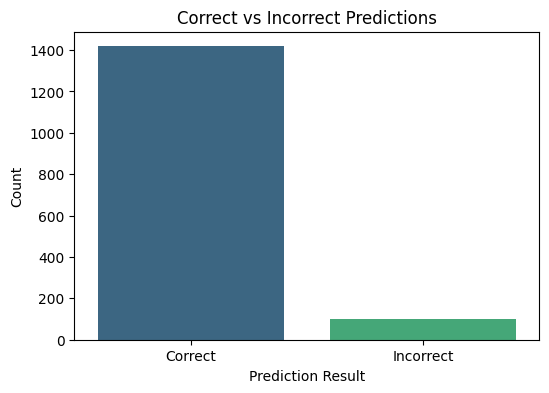

In [46]:
#Correct vs incorrect predictions

plt.figure(figsize=(6, 4))
sns.countplot(data=test_results_df, x='prediction_result', palette='viridis')
plt.title('Correct vs Incorrect Predictions')
plt.xlabel('Prediction Result')
plt.ylabel('Count')
plt.show()

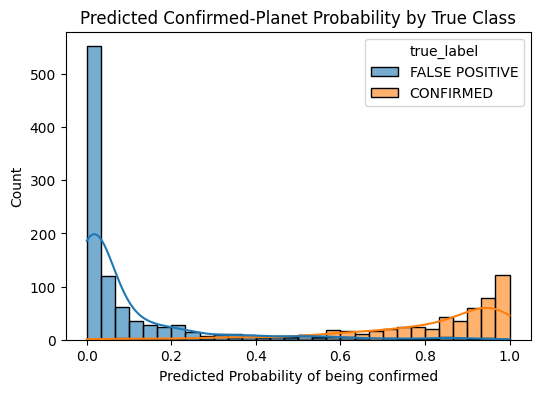

In [47]:
#Predicted probability distribution by true class

plt.figure(figsize=(6,4))
sns.histplot(
    data=test_results_df, x='confirmed_probability', hue='true_label', bins=30, kde=True, alpha=0.6

)
plt.title('Predicted Confirmed-Planet Probability by True Class')
plt.xlabel('Predicted Probability of being confirmed')
plt.ylabel('Count')
plt.show()

<a id="bookmark-model-interpretation"></a>

# Model Interpretation

After evaluating the final model, I interpret which features influence the predictions.

This step is important because the project should not be a black-box classifier only. The goal is to connect machine-learning behavior with meaningful physical and transit-related Kepler features.


In [48]:
# Feature importance from the selected tree-based model

final_model = best_pipeline.named_steps['model']

if hasattr(final_model, 'feature_importances_'):
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': final_model.feature_importances_
    }).sort_values(by='importance', ascending=False)

    display(feature_importance_df)
else:
    print(f"{best_model_name} does not provide built-in feature importance.")
    print("Use permutation importance instead.")

,feature,importance
5,koi_prad,0.183189
8,koi_model_snr,0.133146
0,koi_period,0.101355
2,koi_impact,0.093366
4,koi_depth,0.085332
7,koi_insol,0.084737
6,koi_teq,0.076918
3,koi_duration,0.072008
1,koi_time0bk,0.041380
9,koi_steff,0.040283


/tmp/ipykernel_7616/3259856291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='pastel')


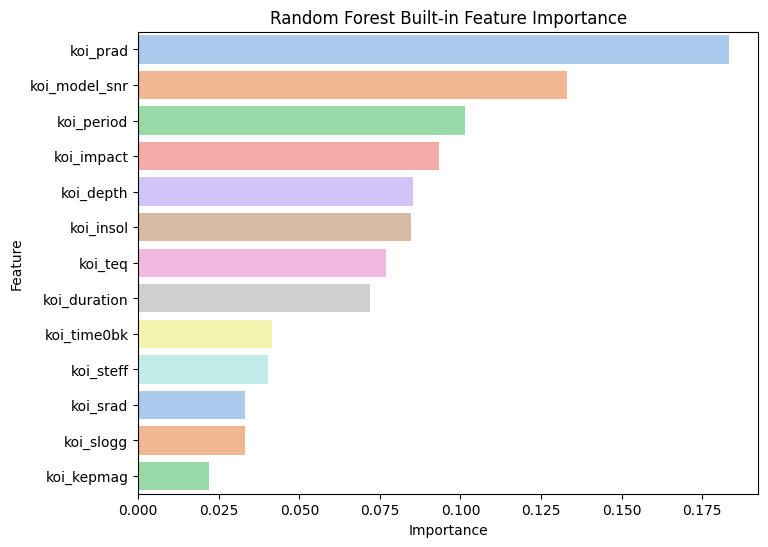

In [49]:
#Plot built-in feature importance for the selected model

if 'feature_importance_df' in globals():
    plt.figure(figsize=(8, 6))
    sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='pastel')
    plt.title(f'{best_model_name} Built-in Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print("Built-in feature importance is not available for the selected model.")


## Permutation Importance

Built-in feature importance can be useful, but it may be biased when features are correlated. Therefore, I also use permutation importance.

Permutation importance checks how much model performance decreases when one feature is randomly shuffled. If shuffling a feature strongly damages performance, that feature is important for the model.


In [50]:
#Permutation importance

from sklearn.inspection import permutation_importance


perm_result = permutation_importance(
    best_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro'
)
perm_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importances_std': perm_result.importances_std
}).sort_values(by='importance_mean', ascending=False)

perm_importance_df


,feature,importance_mean,importances_std
5,koi_prad,0.141910,0.005678
2,koi_impact,0.083596,0.007014
8,koi_model_snr,0.075387,0.007776
3,koi_duration,0.068227,0.004127
0,koi_period,0.059533,0.005298
7,koi_insol,0.043852,0.005007
6,koi_teq,0.028404,0.003683
9,koi_steff,0.019199,0.004418
4,koi_depth,0.018260,0.005193
11,koi_srad,0.008340,0.003290


/tmp/ipykernel_7616/3676518183.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=builtin_top, x='importance', y='feature', order=builtin_top['feature'], ax=axes[0], palette='pastel')
/tmp/ipykernel_7616/3676518183.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_top, x='importance_mean', y='feature', order=perm_top['feature'], ax=axes[1], palette='viridis')


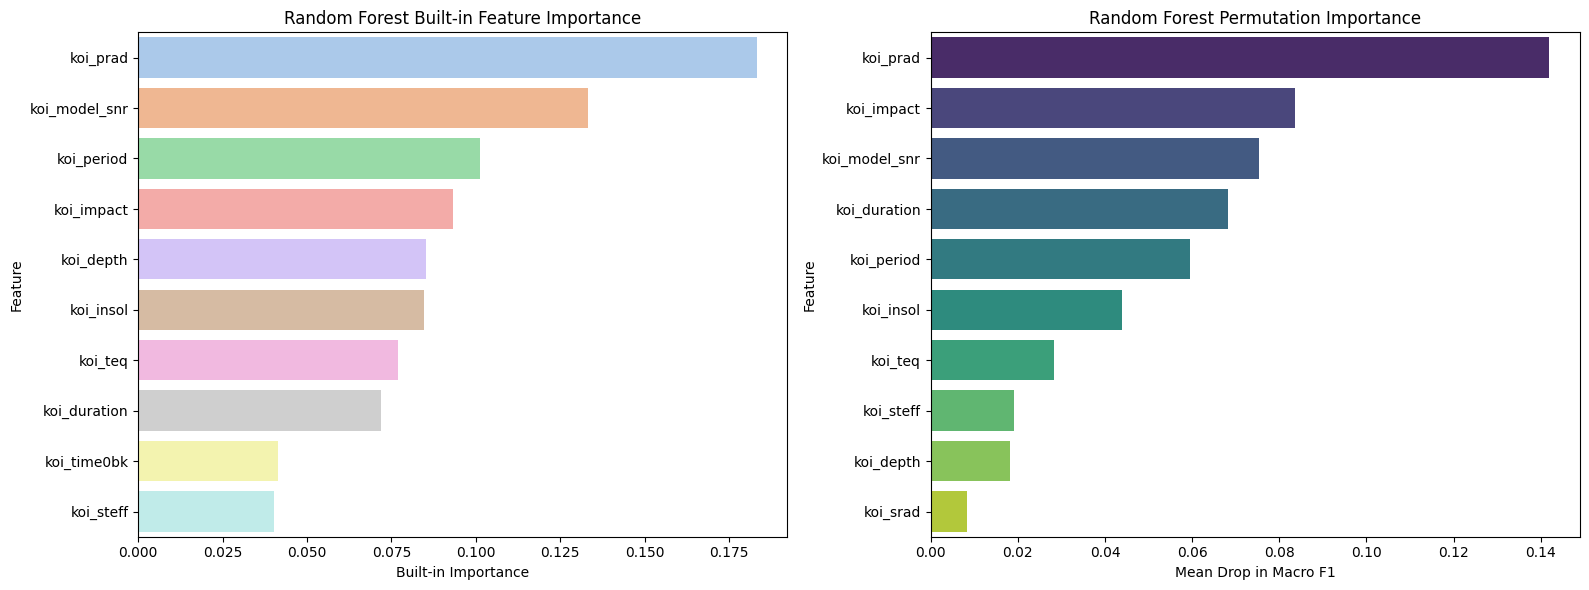

In [51]:
# Compare Built-in Feature Importance and Permutation Importance side by side
# Each plot has its own independent ranking

top_n = 10

# Built-in importance: sort by built-in importance
builtin_top = (feature_importance_df.sort_values(by='importance', ascending=False).head(top_n).copy())

# Permutation importance: sort by permutation importance
perm_top = (perm_importance_df.sort_values(by='importance_mean', ascending=False).head(top_n).copy())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Built-in feature importance plot
sns.barplot(data=builtin_top, x='importance', y='feature', order=builtin_top['feature'], ax=axes[0], palette='pastel')

axes[0].set_title(f'{best_model_name} Built-in Feature Importance')
axes[0].set_xlabel('Built-in Importance')
axes[0].set_ylabel('Feature')


# Permutation importance plot
sns.barplot(data=perm_top, x='importance_mean', y='feature', order=perm_top['feature'], ax=axes[1], palette='viridis')

axes[1].set_title(f'{best_model_name} Permutation Importance')
axes[1].set_xlabel('Mean Drop in Macro F1')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

The built-in Random Forest importance and permutation importance are not expected to be identical. Built-in importance is calculated from how the trees split the training data, while permutation importance measures how much the model performance decreases when each feature is shuffled on the test data. Therefore, permutation importance is usually more useful for model interpretation.

## Interpretation of Feature Importance

The permutation importance results show that `koi_prad` is the most influential feature in the Random Forest model. This means that the estimated planet radius plays the strongest role in distinguishing confirmed exoplanets from false positives.

The next most important features are `koi_impact`, `koi_model_snr`, `koi_duration`, and `koi_period`. These features are strongly connected to the transit signal. For example, `koi_model_snr` measures the signal-to-noise ratio of the transit model, while `koi_duration` and `koi_period` describe the timing and shape of the observed transit. This suggests that the model is mainly learning from physically meaningful transit characteristics rather than random or unrelated information.

Compared with the built-in Random Forest feature importance, the permutation importance gives a slightly different ranking. For example, `koi_depth` had higher importance in the built-in Random Forest result, but its permutation importance is lower. This can happen because some features contain overlapping information. If `koi_depth` is correlated with other features such as `koi_prad`, `koi_model_snr`, or `koi_duration`, then shuffling only `koi_depth` may not reduce the model performance as much, because the model can still use the related features.

Features such as `koi_time0bk` and `koi_kepmag` have very low permutation importance. Their importance means are close to zero and smaller than their standard deviations, so they do not appear to contribute much to the model’s predictive performance.

Overall, the interpretation is scientifically reasonable: the model relies mostly on planet size, transit geometry, signal strength, transit duration, and orbital period. These are meaningful features for separating confirmed exoplanets from false positive signals.


<a id="bookmark-candidate-prioritization"></a>

# Candidate Prioritization: From Classification to Decision Support

After the model is evaluated and interpreted on known labels, I apply it to unresolved `CANDIDATE` objects.

This is the main transition of the project: the model is no longer used only for classification. It becomes a decision-support tool that ranks which unresolved Kepler candidates may be more interesting for further scientific investigation.

## Applying the Model to Unresolved Candidates

After evaluating the final model on known confirmed planets and false positives, I apply it to unresolved Kepler `CANDIDATE` objects.

The model assigns each unresolved candidate a planet-like probability. These probabilities are useful for ranking, but they should not be interpreted as official astronomical confirmation probabilities.


In [52]:
#Predict probabilities for unresolved candidates using the final selected model
X_candidates = candidate_df[feature_cols]

candidate_df['planet_probability'] = best_pipeline.predict_proba(X_candidates)[:, 1]

The next table ranks unresolved Kepler candidates by the model's predicted planet-like probability.

This is not official confirmation. It is a prioritization step that helps decide which candidates may deserve further attention.


In [53]:
#Rank unresolved candidates by predicted planet probability

candidate_ranking = candidate_df[
    ['kepoi_name', 'planet_probability', 'koi_period', 'koi_prad', 'koi_teq', 'koi_model_snr']
    ].sort_values(by='planet_probability', ascending=False)

candidate_ranking


,kepoi_name,planet_probability,koi_period,koi_prad,koi_teq,koi_model_snr
537,K01145.01,0.993333,30.587215,2.32,621.0,33.1
3027,K00426.01,0.986667,16.301413,3.84,805.0,62.4
1404,K01972.01,0.986667,17.791087,2.88,830.0,39.8
1535,K01861.01,0.986667,17.504417,3.56,824.0,47.5
4424,K04526.01,0.983333,30.539293,2.72,669.0,15.0
...,...,...,...,...,...,...
7204,K06097.01,0.000000,93.056544,NaN,NaN,NaN
7177,K06180.01,0.000000,28.201998,NaN,NaN,NaN
1934,K02323.01,0.000000,58.355126,NaN,NaN,NaN
118,K00820.01,0.000000,4.640900,30.09,1155.0,296.9


To make the results easier to present, I group unresolved candidates into three priority levels based on predicted probability.

In [54]:

#Create probability-based priority groups

def priority_group(prob):
  if prob >= 0.90:
    return 'High Priority'
  elif prob >= 0.70:
    return 'Medium Priority'
  else:
    return 'Low Priority'


candidate_df['priority_group'] = candidate_df['planet_probability'].apply(priority_group)
candidate_df['priority_group'].value_counts()


,count
priority_group,
Low Priority,1706
Medium Priority,214
High Priority,58


In [55]:
#Slide 7 table: top planet-like unresolved candidates

slide7_table = (
    candidate_df[['kepoi_name','planet_probability','koi_prad','koi_model_snr','priority_group']].sort_values(by='planet_probability', ascending=False).head(5).copy()
)

slide7_table['planet_probability'] = (slide7_table['planet_probability'] * 100).round(1)
slide7_table['koi_prad'] = slide7_table['koi_prad'].round(2)
slide7_table['koi_model_snr'] = slide7_table['koi_model_snr'].round(1)

slide7_table.columns = ['Candidate','Probability (%)','Radius (Earth)','SNR','Priority']

slide7_table

,Candidate,Probability (%),Radius (Earth),SNR,Priority
537,K01145.01,99.3,2.32,33.1,High Priority
3027,K00426.01,98.7,3.84,62.4,High Priority
1404,K01972.01,98.7,2.88,39.8,High Priority
1535,K01861.01,98.7,3.56,47.5,High Priority
4424,K04526.01,98.3,2.72,15.0,High Priority


#End Of Online Presentation
The rest include some efforts to understand other scientific aspects of ranking by ML.

/tmp/ipykernel_7616/2518974831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= candidate_df, x='priority_group', order=['High Priority', 'Medium Priority', 'Low Priority'], palette='pastel')


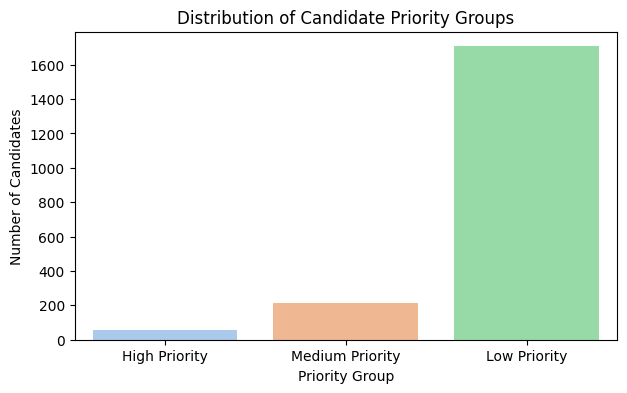

In [56]:
#Candidate priority group distribution

plt.figure(figsize=(7, 4))
sns.countplot(data= candidate_df, x='priority_group', order=['High Priority', 'Medium Priority', 'Low Priority'], palette='pastel')

plt.title('Distribution of Candidate Priority Groups')
plt.xlabel('Priority Group')
plt.ylabel('Number of Candidates')
plt.show()

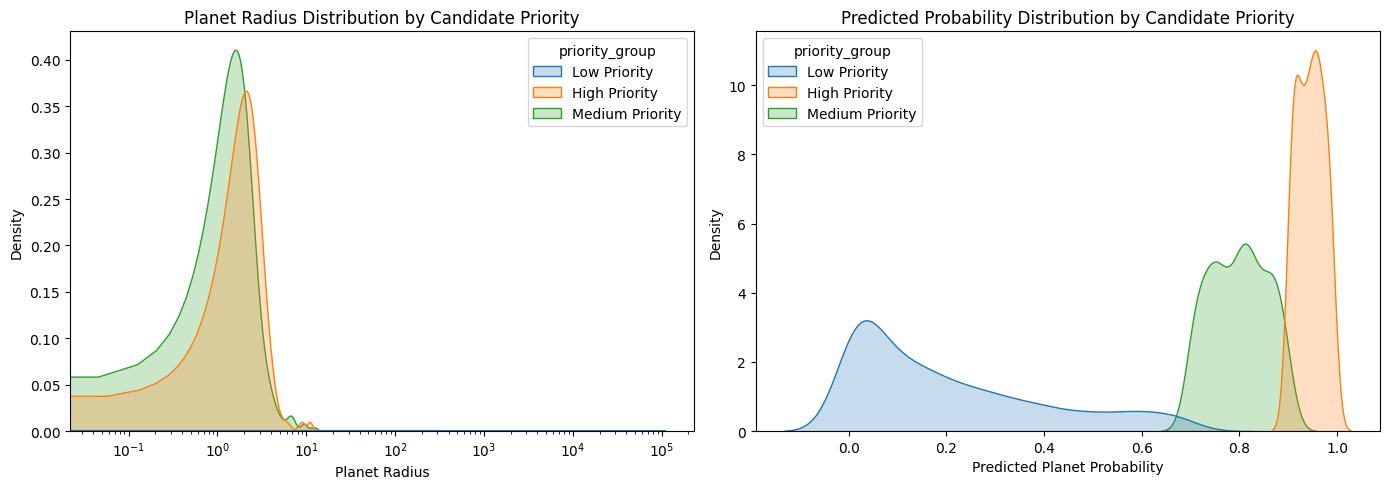

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    data=candidate_df,
    x='koi_prad',
    hue='priority_group',
    fill=True,
    common_norm=False,
    alpha=0.25,
    ax=axes[0]
)

axes[0].set_title('Planet Radius Distribution by Candidate Priority')
axes[0].set_xlabel('Planet Radius')
axes[0].set_ylabel('Density')
axes[0].set_xscale('log')

sns.kdeplot(
    data=candidate_df,
    x='planet_probability',
    hue='priority_group',
    fill=True,
    common_norm=False,
    alpha=0.25,
    ax=axes[1]
)

axes[1].set_title('Predicted Probability Distribution by Candidate Priority')
axes[1].set_xlabel('Predicted Planet Probability')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

### Interpretation of Candidate Priority Distributions

These KDE plots compare the feature distributions of the predicted candidate priority groups.

In the left plot, most High Priority and Medium Priority candidates are concentrated in a smaller planet-radius range. This suggests that candidates with more realistic planet-size values are more likely to receive higher model priority. Low Priority candidates are more widely spread, including very large radius values, which can be less planet-like and more suspicious for false-positive behavior.

However, High Priority and Medium Priority candidates still overlap strongly in planet radius. This means planet radius alone is not enough to explain the model decision. The model is using several features together, such as signal-to-noise ratio, transit depth, impact, duration, and stellar properties.

In the right plot, the predicted probability distributions clearly follow the priority thresholds. High Priority candidates are concentrated close to probability 1, Medium Priority candidates are mostly around 0.7–0.9, and Low Priority candidates are mostly below 0.7. **This confirms that the priority groups were created correctly from the model probabilities.**

Overall, these plots show that the priority groups are meaningful, but they should not be interpreted as official confirmation. They show model-based prioritization: High Priority candidates are more planet-like according to the trained model, while Low Priority candidates are less similar to confirmed planet patterns.

The radius plot shows that high-priority candidates tend to stay in a more realistic planet-radius region, while low-priority candidates are more spread out and include extreme radius values. But because the groups overlap, radius alone cannot separate the candidates. This supports the need for a machine learning model using multiple physical features.

The probability plot mainly confirms that the priority groups were correctly created from predicted probabilities. Therefore, the most useful insight is not only that high-priority candidates have high probability, but that their physical radius distribution is also more concentrated and less extreme.

/tmp/ipykernel_7616/1732884442.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_candidates, x='planet_probability', y='kepoi_name', palette='dark')


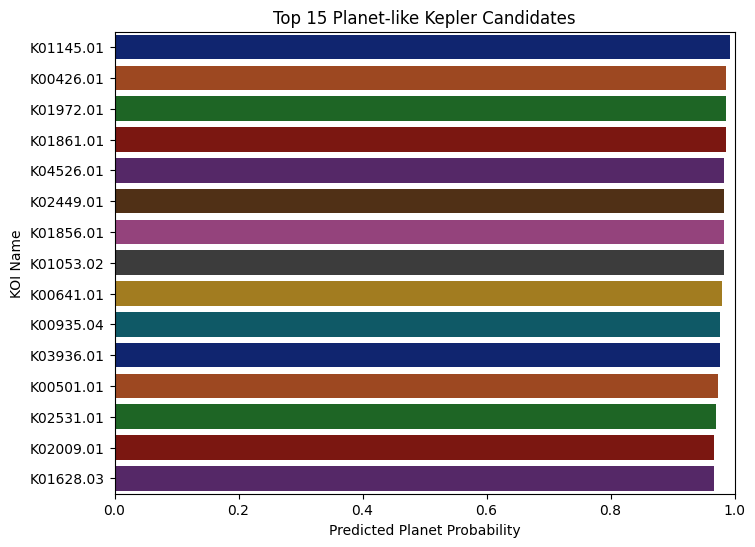

In [58]:
#Top 15 most planet-like candidates

top_candidates = candidate_ranking.head(15).copy()

plt.figure(figsize=(8, 6))
sns.barplot(data=top_candidates, x='planet_probability', y='kepoi_name', palette='dark')

plt.title('Top 15 Planet-like Kepler Candidates')
plt.xlabel('Predicted Planet Probability')
plt.ylabel('KOI Name')
plt.xlim(0, 1)
plt.show()

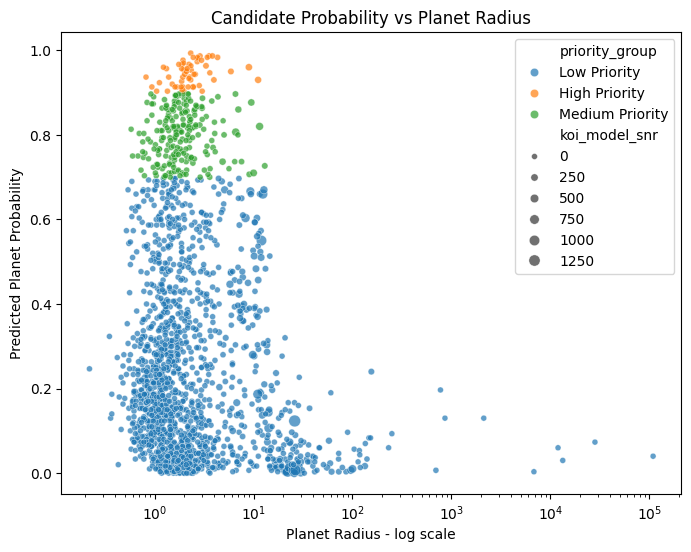

In [59]:
#Candidate probability vs planet radius

plot_candidates = candidate_df[(candidate_df['koi_prad'] > 0) & (candidate_df['planet_probability'].notna())].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_candidates, x='koi_prad', y='planet_probability', hue='priority_group', size='koi_model_snr', alpha=0.7)

plt.xscale('log')
plt.title('Candidate Probability vs Planet Radius')
plt.xlabel('Planet Radius - log scale')
plt.ylabel('Predicted Planet Probability')
plt.show()

<a id="bookmark-unsupervised-similarity"></a>

## Unsupervised Similarity Check for Candidates

Since CANDIDATE objects do not have final labels, I used unsupervised learning as an additional exploratory check.

The clustering model does not directly predict CONFIRMED or FALSE POSITIVE labels. Instead, it groups objects based on their physical features.

Then I compare the clusters with known CONFIRMED and FALSE POSITIVE objects to understand whether each cluster is more planet-like or false-positive-like.

In [60]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#Combine labeled objects and candidates for clustering
unsupervised_df = pd.concat([model_df[feature_cols + ['koi_disposition']], candidate_df[feature_cols + ['koi_disposition']]], axis=0).copy()

unsupervised_df['koi_disposition'].value_counts()

,count
koi_disposition,
FALSE POSITIVE,4839
CONFIRMED,2747
CANDIDATE,1978


In [61]:
# KMeans needs scaled numeric data
cluster_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('cluster', KMeans(n_clusters=2, random_state=42, n_init=10))
])

#Fit clustering model WITHOUT using labels
unsupervised_df['cluster'] = cluster_pipeline.fit_predict(unsupervised_df[feature_cols])

unsupervised_df[['koi_disposition', 'cluster']].value_counts()

,,count
koi_disposition,cluster,
FALSE POSITIVE,0,4811
CONFIRMED,0,2747
CANDIDATE,0,1975
FALSE POSITIVE,1,28
CANDIDATE,1,3


In [62]:
# Use only known labels to interpret the clusters
known_cluster_df = unsupervised_df[
    unsupervised_df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])
].copy()

cluster_counts = pd.crosstab(known_cluster_df['cluster'],known_cluster_df['koi_disposition'])

cluster_percentages = pd.crosstab(known_cluster_df['cluster'],known_cluster_df['koi_disposition'],normalize='index') * 100

cluster_counts

koi_disposition,CONFIRMED,FALSE POSITIVE
cluster,,
0,2747,4811
1,0,28


In [63]:
cluster_percentages.round(2)

koi_disposition,CONFIRMED,FALSE POSITIVE
cluster,,
0,36.35,63.65
1,0.00,100.00


In [64]:
# The cluster with higher percentage of CONFIRMED objects is called confirmed-like
confirmed_like_cluster = cluster_percentages['CONFIRMED'].idxmax()
false_positive_like_cluster = cluster_percentages['CONFIRMED'].idxmin()

cluster_name_map = {
    confirmed_like_cluster: 'Confirmed-like cluster',
    false_positive_like_cluster: 'False-positive-like cluster'
}

cluster_name_map

{np.int32(0): 'Confirmed-like cluster',
 np.int32(1): 'False-positive-like cluster'}

In [65]:
candidate_unsupervised = unsupervised_df[unsupervised_df['koi_disposition'] == 'CANDIDATE'].copy()

candidate_unsupervised['unsupervised_group'] = candidate_unsupervised['cluster'].map(cluster_name_map)

candidate_unsupervised['unsupervised_group'].value_counts()

,count
unsupervised_group,
Confirmed-like cluster,1975
False-positive-like cluster,3


In [66]:
candidate_unsupervised_results = candidate_df.copy()

candidate_unsupervised_results['cluster'] = candidate_unsupervised['cluster'].values
candidate_unsupervised_results['unsupervised_group'] = candidate_unsupervised['unsupervised_group'].values

candidate_unsupervised_results[
    ['kepoi_name', 'planet_probability', 'priority_group', 'unsupervised_group',
     'koi_period', 'koi_prad', 'koi_model_snr']
].sort_values(by='planet_probability', ascending=False).head(15)

,kepoi_name,planet_probability,priority_group,unsupervised_group,koi_period,koi_prad,koi_model_snr
537,K01145.01,0.993333,High Priority,Confirmed-like cluster,30.587215,2.32,33.1
3027,K00426.01,0.986667,High Priority,Confirmed-like cluster,16.301413,3.84,62.4
1404,K01972.01,0.986667,High Priority,Confirmed-like cluster,17.791087,2.88,39.8
1535,K01861.01,0.986667,High Priority,Confirmed-like cluster,17.504417,3.56,47.5
4424,K04526.01,0.983333,High Priority,Confirmed-like cluster,30.539293,2.72,15.0
2187,K02449.01,0.983333,High Priority,Confirmed-like cluster,53.358044,3.41,19.7
1496,K01856.01,0.983333,High Priority,Confirmed-like cluster,46.299105,4.33,55.0
7238,K01053.02,0.983333,High Priority,Confirmed-like cluster,46.245164,2.46,15.5
3436,K00641.01,0.980000,High Priority,Confirmed-like cluster,14.851855,2.73,58.3
304,K00935.04,0.976667,High Priority,Confirmed-like cluster,9.617314,1.94,18.2


In [67]:
# Unsupervised method comparison on known labels only
# CONFIRMED vs FALSE POSITIVE


from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.manifold import TSNE

# 1. Use only objects with final known labels
known_df = unsupervised_df[
    unsupervised_df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])
].copy()

X_known = known_df[feature_cols]
y_known = known_df['koi_disposition']

# 2. Preprocess data
# QuantileTransformer helps reduce the effect of extreme outliers
preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer(
        output_distribution='normal',
        random_state=42,
        n_quantiles=min(1000, len(known_df))
    ))
])

X_scaled = preprocess.fit_transform(X_known)

# 3. Try different unsupervised methods
methods = {
    'KMeans': KMeans(n_clusters=2, random_state=42, n_init=20),
    'Agglomerative': AgglomerativeClustering(n_clusters=2),
    'Gaussian Mixture': GaussianMixture(n_components=2, random_state=42)
}

results = []
cluster_outputs = {}

for name, model in methods.items():
    cluster_labels = model.fit_predict(X_scaled)
    cluster_outputs[name] = cluster_labels

    ari = adjusted_rand_score(y_known, cluster_labels)
    nmi = normalized_mutual_info_score(y_known, cluster_labels)
    sil = silhouette_score(X_scaled, cluster_labels)

    results.append({
        'method': name,
        'ARI': ari,
        'NMI': nmi,
        'Silhouette': sil
    })

results_df = pd.DataFrame(results).sort_values(by='ARI', ascending=False)

display(results_df)

,method,ARI,NMI,Silhouette
1,Agglomerative,0.052950,0.153921,0.167625
0,KMeans,0.036775,0.034294,0.183087
2,Gaussian Mixture,-0.039840,0.081101,0.132112


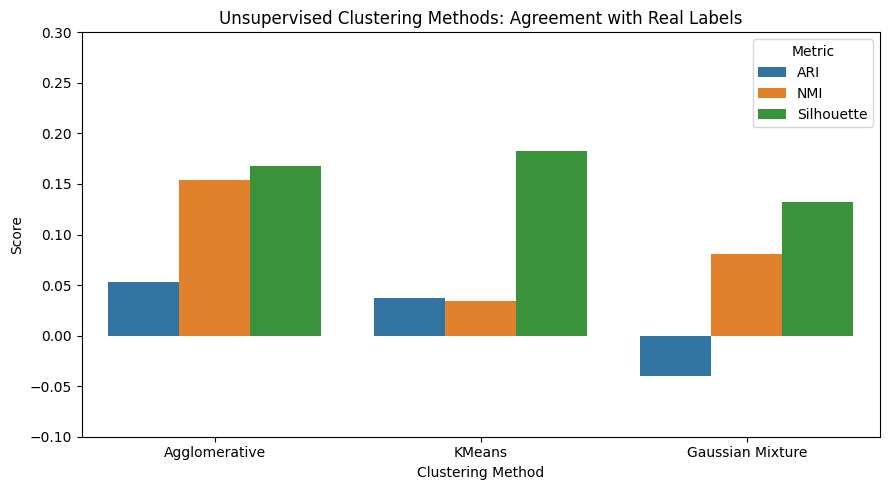

In [68]:
# Plot comparison of unsupervised clustering methods


results_long = results_df.melt(
    id_vars='method',
    value_vars=['ARI', 'NMI', 'Silhouette'],
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_long,
    x='method',
    y='score',
    hue='metric'
)

plt.title('Unsupervised Clustering Methods: Agreement with Real Labels')
plt.xlabel('Clustering Method')
plt.ylabel('Score')
plt.ylim(-0.1, 0.3)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

I tested several unsupervised clustering methods to see whether the Kepler objects naturally form groups similar to the official labels. The results were weak: the ARI and NMI scores were close to zero, which means the discovered clusters did not match the real classifications well. The Silhouette scores were also low, showing that the clusters were not strongly separated. Therefore, unsupervised clustering is not suitable as the main classification method for this project. This supports the decision to use supervised machine learning models for the final prediction task.

<a id="bookmark-reference-planet-similarity"></a>

## Reference Planet Similarity Check

In [the video-related research](https://www.youtube.com/watch?v=G99XxEDbNEs), `Kepler-1649c` is the main planet repeatedly connected with an Earth-like / potentially interesting Kepler discovery. I also include several well-known Kepler habitable-zone reference planets as comparison examples.

This section does **not** prove habitability and does **not** officially confirm candidates.

The goal is only to ask:

> Which unresolved `CANDIDATE` objects have physical feature values closest to known interesting Kepler planets?

I use a distance-based similarity score on selected physical features. A candidate with high supervised planet probability and high reference similarity can be considered more scientifically interesting for follow-up.


In [69]:
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
import re

# Reference planets mentioned in the video
# K2-18b is included for checking, but it may not exist in this Kepler KOI dataset.
# KOI-5 System is not a planet, so we use KOI-5Ab instead.

reference_planet_names = [
    'K2-18b',
    'Kepler-186f',
    'Kepler-1649c',
    'KOI-5Ab'
]

reference_planet_names


['K2-18b', 'Kepler-186f', 'Kepler-1649c', 'KOI-5Ab']

In [70]:
import re

def normalize_planet_name(name):
    return re.sub(r'[^a-z0-9]', '', str(name).lower())


# Manual aliases for names that may appear differently in the KOI table
reference_aliases = {
    'K2-18b': ['K2-18b', 'K2 18 b', 'K2-18 b'],
    'Kepler-186f': ['Kepler-186f', 'Kepler-186 f'],
    'Kepler-1649c': ['Kepler-1649c', 'Kepler-1649 c'],
    'KOI-5Ab': ['KOI-5Ab', 'KOI-5 b', 'K00005.01', 'K00005']
}

name_columns = [col for col in ['kepler_name', 'kepoi_name'] if col in df.columns]

matched_reference_rows = []
missing_reference_names = []

for planet_name in reference_planet_names:
    aliases = reference_aliases.get(planet_name, [planet_name])
    normalized_aliases = [normalize_planet_name(alias) for alias in aliases]

    mask = pd.Series(False, index=df.index)

    for col in name_columns:
        normalized_col = df[col].apply(normalize_planet_name)

        for alias in normalized_aliases:
            # Exact match for Kepler names
            mask = mask | normalized_col.eq(alias)

            # Special case: KOI-5 system / K00005 entries
            if planet_name == 'KOI-5Ab':
                mask = mask | normalized_col.str.startswith('k00005')

    matches = df[mask].copy()

    if len(matches) > 0:
        matches['matched_reference_name'] = planet_name
        matched_reference_rows.append(matches)
    else:
        missing_reference_names.append(planet_name)

if matched_reference_rows:
    reference_df = pd.concat(matched_reference_rows, axis=0).drop_duplicates()
else:
    reference_df = pd.DataFrame()

print("Found reference rows:", reference_df.shape[0])
print("Missing reference names:", missing_reference_names)

display_cols = ['matched_reference_name', 'kepler_name', 'kepoi_name', 'koi_disposition'] + feature_cols
display_cols = [col for col in display_cols if col in reference_df.columns]

reference_df[display_cols]

Found reference rows: 4
Missing reference names: ['K2-18b']


,matched_reference_name,kepler_name,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag
3868,Kepler-186f,Kepler-186 f,K00571.05,CONFIRMED,129.945392,176.822850,0.909,5.7860,500.1,1.18,177.0,0.23,13.1,3751.0,4.800,0.443,14.625
3043,Kepler-1649c,Kepler-1649 c,K03138.02,CONFIRMED,19.535255,148.203740,0.702,1.0130,1732.0,0.53,161.0,0.16,5.9,2703.0,5.274,0.118,17.131
2760,KOI-5Ab,NaN,K00005.01,CANDIDATE,4.780328,132.974086,0.952,2.0253,960.8,7.14,1441.0,1020.05,380.8,5937.0,4.012,1.787,11.665
3239,KOI-5Ab,NaN,K00005.02,FALSE POSITIVE,7.051856,133.366902,NaN,3.6900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.665


For similarity, I use mostly physical and habitability-related columns instead of all model features.

I focus on features such as orbital period, planet radius, equilibrium temperature, insolation, and stellar properties.

I do **not** use leakage columns like `koi_score`, `koi_pdisposition`, or `koi_fpflag_*`.


In [71]:
# Features used for similarity to reference planets
reference_similarity_features = [
    'koi_period',
    'koi_prad',
    'koi_teq',
    'koi_insol',
    'koi_steff',
    'koi_slogg',
    'koi_srad'
]

# Keep only features that exist in the dataset and were selected in this project
reference_similarity_features = [
    col for col in reference_similarity_features
    if col in df.columns and col in feature_cols
]

reference_similarity_features


['koi_period',
 'koi_prad',
 'koi_teq',
 'koi_insol',
 'koi_steff',
 'koi_slogg',
 'koi_srad']

In [72]:
if reference_df.empty:
    raise ValueError(
        "No reference planets were found in this dataset. "
        "Check the reference_planet_names list or inspect the kepler_name column.")

if len(reference_similarity_features) == 0:
    raise ValueError(
        "No reference similarity features were found. "
        "Check feature_cols and the reference_similarity_features list.")

# Fit preprocessing on known labeled objects only
# This keeps the transformation consistent with the supervised project logic.
reference_similarity_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])

reference_similarity_preprocess.fit(model_df[reference_similarity_features])

X_reference_scaled = reference_similarity_preprocess.transform(reference_df[reference_similarity_features])

X_candidates_scaled = reference_similarity_preprocess.transform(candidate_df[reference_similarity_features])

# Euclidean distance in scaled feature space:
# smaller distance means more similar to the reference planets.
distance_matrix = pairwise_distances(X_candidates_scaled,X_reference_scaled,metric='euclidean')

min_distances = distance_matrix.min(axis=1)
closest_reference_index = distance_matrix.argmin(axis=1)

candidate_reference_similarity = candidate_df.copy()

candidate_reference_similarity['reference_min_distance'] = min_distances
candidate_reference_similarity['closest_reference_planet'] = (reference_df.iloc[closest_reference_index]['matched_reference_name'].values)

# Convert distance to similarity:
# smaller distance -> larger score
candidate_reference_similarity['reference_similarity_score'] = (
    1 / (1 + candidate_reference_similarity['reference_min_distance'])
)

candidate_reference_similarity[
    [
        'kepoi_name',
        'planet_probability',
        'priority_group',
        'closest_reference_planet',
        'reference_similarity_score',
        'koi_period',
        'koi_prad',
        'koi_teq',
        'koi_insol',
        'koi_model_snr'
    ]
].sort_values(by='reference_similarity_score', ascending=False).tail()


,kepoi_name,planet_probability,priority_group,closest_reference_planet,reference_similarity_score,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
3399,K00099.01,0.423333,Low Priority,Kepler-186f,0.051285,2190.701035,3.12,109.0,0.03,94.8
9229,K08109.01,0.093333,Low Priority,KOI-5Ab,0.036991,218.771117,250.20,1997.0,3757.91,8.4
5545,K07791.01,0.060000,Low Priority,KOI-5Ab,0.036530,106.187320,231.85,2660.0,11829.18,8.6
7151,K05873.01,0.040000,Low Priority,KOI-5Ab,0.027662,217.170081,109061.00,802.0,97.62,9.5
342,K01174.01,0.616667,Low Priority,Kepler-186f,0.000860,129995.778400,2.99,25.0,0.00,35.7


In [73]:
# Scale reference similarity between 0 and 1
similarity_scaler = MinMaxScaler()

candidate_reference_similarity['reference_similarity_scaled'] = (
    similarity_scaler.fit_transform(
        candidate_reference_similarity[['reference_similarity_score']]
    )
)

# Combine supervised model probability with reference-planet similarity.
# The supervised model remains the main signal.
# Reference similarity is only a supporting scientific-interest score.
candidate_reference_similarity['reference_based_priority_score'] = (
    0.70 * candidate_reference_similarity['planet_probability']
    + 0.30 * candidate_reference_similarity['reference_similarity_scaled']
)

reference_based_ranking = candidate_reference_similarity.sort_values(
    by='reference_based_priority_score',
    ascending=False
)

reference_based_ranking[
    [
        'kepoi_name',
        'planet_probability',
        'reference_similarity_scaled',
        'reference_based_priority_score',
        'priority_group',
        'closest_reference_planet',
        'koi_period',
        'koi_prad',
        'koi_teq',
        'koi_insol',
        'koi_model_snr'
    ]
].head(20)


,kepoi_name,planet_probability,reference_similarity_scaled,reference_based_priority_score,priority_group,closest_reference_planet,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
1920,K02159.01,0.956667,0.809327,0.912465,High Priority,KOI-5Ab,7.596700,1.32,964.0,204.34,24.5
2928,K00350.01,0.943333,0.840101,0.912364,High Priority,KOI-5Ab,12.990651,2.02,790.0,92.12,42.5
537,K01145.01,0.993333,0.675002,0.897834,High Priority,KOI-5Ab,30.587215,2.32,621.0,35.08,33.1
3027,K00426.01,0.986667,0.675349,0.893271,High Priority,KOI-5Ab,16.301413,3.84,805.0,99.08,62.4
2992,K00522.01,0.963333,0.727746,0.892657,High Priority,KOI-5Ab,12.829935,3.31,734.0,68.41,79.6
3178,K00501.01,0.973333,0.703349,0.892338,High Priority,KOI-5Ab,24.796280,2.70,664.0,45.92,43.6
2847,K02972.01,0.953333,0.735256,0.887910,High Priority,KOI-5Ab,13.251121,1.98,850.0,123.32,15.2
4379,K04452.01,0.960000,0.711986,0.885596,High Priority,KOI-5Ab,12.857559,1.23,860.0,129.15,14.2
8960,K04032.05,0.936667,0.759370,0.883478,High Priority,KOI-5Ab,7.235242,0.82,948.0,191.14,15.2
3015,K00525.01,0.930000,0.737262,0.872178,High Priority,KOI-5Ab,11.530293,3.98,873.0,137.08,57.6


In [76]:
# Reference-specific similarity ranking
# Top 10 candidates for each reference planet separately


from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import pairwise_distances

# 1. Select features that exist in both candidate table and reference table
similarity_features = [
    col for col in feature_cols
    if col in candidate_reference_similarity.columns and col in reference_df.columns]

print("Features used for reference similarity:")
print(similarity_features)

# 2. Prepare candidate table
candidates_for_ref = candidate_reference_similarity.copy()

# Keep one row per KOI candidate
candidates_for_ref = candidates_for_ref.drop_duplicates(subset=['kepoi_name']).reset_index(drop=True)

# 3. Prepare reference planets
refs_for_similarity = reference_df.copy()

# Keep only real reference planet rows
# For KOI-5Ab, keep K00005.01 only, not K00005.02
refs_for_similarity = refs_for_similarity[
    (refs_for_similarity['koi_disposition'] == 'CONFIRMED') |
    (refs_for_similarity['kepoi_name'] == 'K00005.01')
].copy()

refs_for_similarity = refs_for_similarity[
    ~(
        (refs_for_similarity['matched_reference_name'] == 'KOI-5Ab') &
        (refs_for_similarity['kepoi_name'] != 'K00005.01')
    )
].reset_index(drop=True)

print("\nReference planets used:")
display(refs_for_similarity[['matched_reference_name', 'kepler_name', 'kepoi_name', 'koi_disposition']])

# 4. Preprocess candidates and reference planets together
# This makes their numerical features comparable
combined_features = pd.concat(
    [
        candidates_for_ref[similarity_features],
        refs_for_similarity[similarity_features]
    ],
    axis=0
)

similarity_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

combined_scaled = similarity_preprocess.fit_transform(combined_features)

X_candidates_scaled = combined_scaled[:len(candidates_for_ref)]
X_refs_scaled = combined_scaled[len(candidates_for_ref):]

# 5. Compute distance from every candidate to every reference planet
distance_matrix = pairwise_distances(
    X_candidates_scaled,
    X_refs_scaled,
    metric='euclidean'
)

# Convert distance to similarity
# Smaller distance means more similar
# This formula makes higher score = more similar
similarity_matrix = 1 / (1 + distance_matrix)

# 6. Build a long table:
# Each candidate appears once for each reference planet
reference_specific_rows = []

for ref_idx, ref_row in refs_for_similarity.iterrows():
    temp = candidates_for_ref.copy()

    temp['reference_planet'] = ref_row['matched_reference_name']
    temp['reference_kepoi_name'] = ref_row['kepoi_name']
    temp['distance_to_reference'] = distance_matrix[:, ref_idx]
    temp['reference_similarity_score'] = similarity_matrix[:, ref_idx]

    reference_specific_rows.append(temp)

reference_specific_similarity = pd.concat(
    reference_specific_rows,
    axis=0
).reset_index(drop=True)

# 7. Scale similarity separately inside each reference planet group
# So each reference planet gets its own fair top candidates
def scale_inside_group(series):
    if series.nunique() <= 1:
        return pd.Series(1.0, index=series.index)

    scaled_values = MinMaxScaler().fit_transform(series.to_frame()).ravel()
    return pd.Series(scaled_values, index=series.index)

reference_specific_similarity['reference_similarity_scaled'] = (
    reference_specific_similarity
    .groupby('reference_planet')['reference_similarity_score']
    .transform(scale_inside_group)
)

# 8. Combine supervised probability with reference-specific similarity
reference_specific_similarity['reference_specific_priority_score'] = (
    0.70 * reference_specific_similarity['planet_probability']
    + 0.30 * reference_specific_similarity['reference_similarity_scaled']
)

# 9. Get top 10 candidates for each reference planet
top10_each_reference = (
    reference_specific_similarity
    .sort_values(
        by=['reference_planet', 'reference_specific_priority_score'],
        ascending=[True, False]
    )
    .groupby('reference_planet', group_keys=False)
    .head(10)
)

# 10. Display separate tables
display_cols = [
    'reference_planet',
    'kepoi_name',
    'planet_probability',
    'reference_similarity_scaled',
    'reference_specific_priority_score',
    'priority_group',
    'koi_period',
    'koi_prad',
    'koi_teq',
    'koi_insol',
    'koi_model_snr'
]

display_cols = [col for col in display_cols if col in top10_each_reference.columns]

for ref_name, group in top10_each_reference.groupby('reference_planet'):
    print(f"\nTop 10 candidates similar to {ref_name}:")
    display(
        group[display_cols]
        .sort_values(by='reference_specific_priority_score', ascending=False)
        .reset_index(drop=True)
    )

Features used for reference similarity:
['koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag']

Reference planets used:


,matched_reference_name,kepler_name,kepoi_name,koi_disposition
0,Kepler-186f,Kepler-186 f,K00571.05,CONFIRMED
1,Kepler-1649c,Kepler-1649 c,K03138.02,CONFIRMED
2,KOI-5Ab,NaN,K00005.01,CANDIDATE



Top 10 candidates similar to KOI-5Ab:


,reference_planet,kepoi_name,planet_probability,reference_similarity_scaled,reference_specific_priority_score,priority_group,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
0,KOI-5Ab,K01145.01,0.993333,0.016587,0.700309,High Priority,30.587215,2.32,621.0,35.08,33.1
1,KOI-5Ab,K00426.01,0.986667,0.018103,0.696098,High Priority,16.301413,3.84,805.0,99.08,62.4
2,KOI-5Ab,K01861.01,0.986667,0.017314,0.695861,High Priority,17.504417,3.56,824.0,108.78,47.5
3,KOI-5Ab,K01972.01,0.986667,0.016932,0.695746,High Priority,17.791087,2.88,830.0,112.09,39.8
4,KOI-5Ab,K01856.01,0.983333,0.017698,0.693643,High Priority,46.299105,4.33,592.0,29.04,55.0
5,KOI-5Ab,K02449.01,0.983333,0.015993,0.693131,High Priority,53.358044,3.41,474.0,11.94,19.7
6,KOI-5Ab,K01053.02,0.983333,0.015807,0.693075,High Priority,46.245164,2.46,519.0,17.15,15.5
7,KOI-5Ab,K04526.01,0.983333,0.015789,0.693070,High Priority,30.539293,2.72,669.0,47.46,15.0
8,KOI-5Ab,K00641.01,0.980000,0.017823,0.691347,High Priority,14.851855,2.73,457.0,10.30,58.3
9,KOI-5Ab,K03936.01,0.976667,0.017062,0.688785,High Priority,141.608555,2.98,290.0,1.68,43.3



Top 10 candidates similar to Kepler-1649c:


,reference_planet,kepoi_name,planet_probability,reference_similarity_scaled,reference_specific_priority_score,priority_group,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
0,Kepler-1649c,K03119.01,0.913333,1.000000,0.939333,High Priority,2.184438,0.94,529.0,18.41,19.7
1,Kepler-1649c,K03034.01,0.890000,0.864079,0.882224,Medium Priority,31.020917,1.66,291.0,1.70,15.1
2,Kepler-1649c,K02531.01,0.970000,0.632773,0.868832,High Priority,17.699739,1.96,523.0,17.73,19.8
3,Kepler-1649c,K05327.01,0.870000,0.862665,0.867800,Medium Priority,5.433613,2.09,548.0,21.27,17.9
4,Kepler-1649c,K02992.01,0.856667,0.861152,0.858012,Medium Priority,82.659517,2.03,233.0,0.70,17.1
5,Kepler-1649c,K02900.01,0.953333,0.602919,0.848209,High Priority,46.151253,2.08,423.0,7.59,17.1
6,Kepler-1649c,K02449.01,0.983333,0.530148,0.847378,High Priority,53.358044,3.41,474.0,11.94,19.7
7,Kepler-1649c,K01053.02,0.983333,0.527154,0.846480,High Priority,46.245164,2.46,519.0,17.15,15.5
8,Kepler-1649c,K02862.01,0.800000,0.946230,0.843869,Medium Priority,24.575252,1.64,316.0,2.35,12.1
9,Kepler-1649c,K02453.01,0.876667,0.761524,0.842124,Medium Priority,1.530515,0.84,608.0,32.46,23.2



Top 10 candidates similar to Kepler-186f:


,reference_planet,kepoi_name,planet_probability,reference_similarity_scaled,reference_specific_priority_score,priority_group,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
0,Kepler-186f,K02124.01,0.840000,1.000000,0.888000,Medium Priority,42.337580,1.45,311.0,2.21,18.1
1,Kepler-186f,K03034.01,0.890000,0.863317,0.881995,Medium Priority,31.020917,1.66,291.0,1.70,15.1
2,Kepler-186f,K02401.01,0.920000,0.787963,0.880389,High Priority,38.229204,1.51,359.0,3.92,21.0
3,Kepler-186f,K02900.01,0.953333,0.676356,0.870240,High Priority,46.151253,2.08,423.0,7.59,17.1
4,Kepler-186f,K05458.01,0.913333,0.748465,0.863873,High Priority,56.648588,2.19,377.0,4.77,11.8
5,Kepler-186f,K02531.01,0.970000,0.611649,0.862495,High Priority,17.699739,1.96,523.0,17.73,19.8
6,Kepler-186f,K02449.01,0.983333,0.532175,0.847986,High Priority,53.358044,3.41,474.0,11.94,19.7
7,Kepler-186f,K01053.02,0.983333,0.531904,0.847905,High Priority,46.245164,2.46,519.0,17.15,15.5
8,Kepler-186f,K02882.01,0.866667,0.758208,0.834129,Medium Priority,75.858003,2.72,281.0,1.47,16.1
9,Kepler-186f,K02560.01,0.913333,0.633733,0.829453,High Priority,18.120939,1.68,543.0,20.58,15.8


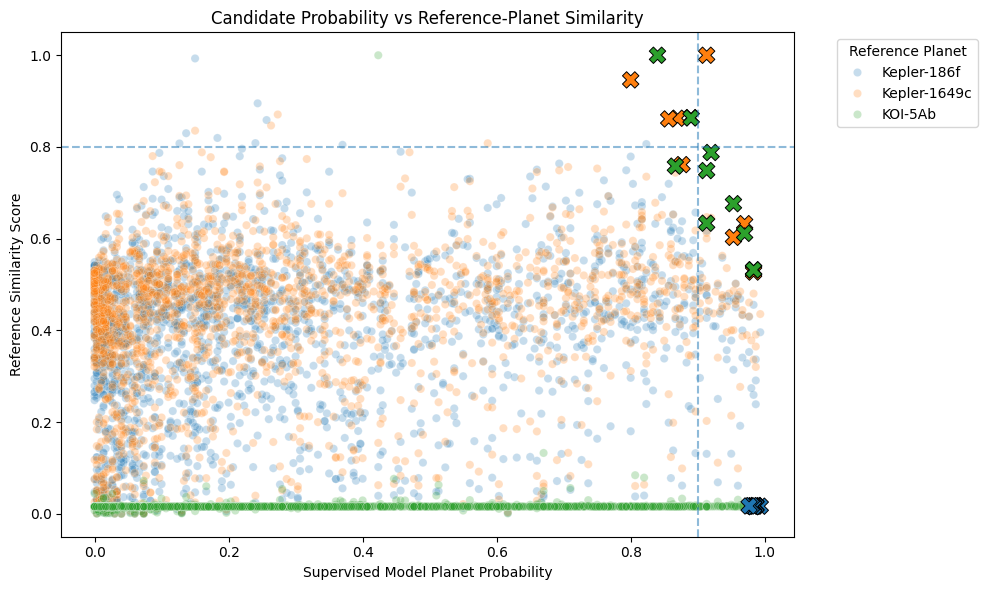

In [77]:

# Plot: model probability vs reference similarity


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=reference_specific_similarity,
    x='planet_probability',
    y='reference_similarity_scaled',
    hue='reference_planet',
    alpha=0.25,
    s=35
)

# Highlight top 10 candidates for each reference planet
sns.scatterplot(
    data=top10_each_reference,
    x='planet_probability',
    y='reference_similarity_scaled',
    hue='reference_planet',
    marker='X',
    s=140,
    edgecolor='black',
    linewidth=0.7,
    legend=False
)

plt.axvline(0.90, linestyle='--', alpha=0.5)
plt.axhline(0.80, linestyle='--', alpha=0.5)

plt.title('Candidate Probability vs Reference-Planet Similarity')
plt.xlabel('Supervised Model Planet Probability')
plt.ylabel('Reference Similarity Score')
plt.legend(title='Reference Planet', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This plot compares two important signals for each candidate: the supervised model planet probability and the similarity to selected reference planets. The x-axis shows how likely the candidate is to be a planet according to the trained supervised model, while the y-axis shows how similar the candidate is to a known reference planet after feature scaling.

The most interesting candidates are located in the upper-right area of the plot, where both the model probability and the reference similarity are high. These objects are not only predicted as likely planets, but also share numerical feature patterns with scientifically interesting known planets. Therefore, they can be considered strong candidates for future follow-up investigation.

The highlighted X markers show the top selected candidates for each reference planet. The result suggests that some candidates are especially similar to KOI-5Ab and Kepler-1649c while also having high model probability. For Kepler-186f, some high-probability candidates have lower similarity, which shows that model confidence and reference similarity do not always select the same objects.

Overall, this visualization supports the idea that the final ranking should not rely only on classification probability. Combining supervised model prediction with reference-planet similarity gives a more informative priority score for selecting scientifically interesting exoplanet candidates.


**Interpretation**

This reference similarity score is not an official astronomical validation metric.

A high score means that the candidate is physically closer to known interesting Kepler planets in the selected feature space.

The best candidates are the ones that have both:

- high supervised `planet_probability`, and
- high `reference_similarity_scaled`.

This gives an additional scientific-priority view before building the final custom priority score.


<a id="bookmark-consensus-candidates"></a>

## Consensus Candidates: Priority + Reference Planet Similarity

In this section, I combine two different ranking ideas:

1. **Supervised model priority**: candidates with high predicted planet probability.
2. **Reference planet similarity**: candidates with feature values close to selected known exoplanets from the video.

The intersection gives a stronger shortlist of candidates that are important in both analyses.

This does **not** confirm the candidates and does **not** prove habitability. It only highlights candidates that are both planet-like according to the model and physically similar to the selected reference planets.


In [78]:
# Intersection 1:
# High Priority candidates that are also in the top 20% for reference-planet similarity

similarity_threshold = candidate_reference_similarity['reference_similarity_scaled'].quantile(0.80)

priority_similarity_intersection =candidate_reference_similarity[(candidate_reference_similarity['priority_group'] == 'High Priority') & (candidate_reference_similarity['reference_similarity_scaled'] >= similarity_threshold)].copy()

priority_similarity_intersection = priority_similarity_intersection.sort_values(by= ['planet_probability', 'reference_similarity_scaled', 'reference_based_priority_score'], ascending=False)

priority_similarity_intersection[
    [
        'kepoi_name',
        'planet_probability',
        'priority_group',
        'reference_similarity_scaled',
        'closest_reference_planet',
        'reference_based_priority_score',
        'koi_period',
        'koi_prad',
        'koi_teq',
        'koi_insol',
        'koi_model_snr'
    ]
].head(20)


,kepoi_name,planet_probability,priority_group,reference_similarity_scaled,closest_reference_planet,reference_based_priority_score,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
537,K01145.01,0.993333,High Priority,0.675002,KOI-5Ab,0.897834,30.587215,2.32,621.0,35.08,33.1
3027,K00426.01,0.986667,High Priority,0.675349,KOI-5Ab,0.893271,16.301413,3.84,805.0,99.08,62.4
3178,K00501.01,0.973333,High Priority,0.703349,KOI-5Ab,0.892338,24.796280,2.70,664.0,45.92,43.6
2992,K00522.01,0.963333,High Priority,0.727746,KOI-5Ab,0.892657,12.829935,3.31,734.0,68.41,79.6
4379,K04452.01,0.960000,High Priority,0.711986,KOI-5Ab,0.885596,12.857559,1.23,860.0,129.15,14.2
1920,K02159.01,0.956667,High Priority,0.809327,KOI-5Ab,0.912465,7.596700,1.32,964.0,204.34,24.5
2847,K02972.01,0.953333,High Priority,0.735256,KOI-5Ab,0.887910,13.251121,1.98,850.0,123.32,15.2
2928,K00350.01,0.943333,High Priority,0.840101,KOI-5Ab,0.912364,12.990651,2.02,790.0,92.12,42.5
1884,K02226.01,0.943333,High Priority,0.678188,KOI-5Ab,0.863790,8.463544,2.51,805.0,99.37,26.1
8960,K04032.05,0.936667,High Priority,0.759370,KOI-5Ab,0.883478,7.235242,0.82,948.0,191.14,15.2


In [79]:
# Intersection 2:
# Candidates that appear in both:
# top N by supervised planet probability
# top N by reference-planet similarity

top_n = 20

top_supervised_candidates = set(
    candidate_ranking.head(top_n)['kepoi_name']
)

top_reference_similarity_candidates = set(
    candidate_reference_similarity
    .sort_values(by='reference_similarity_scaled', ascending=False)
    .head(top_n)['kepoi_name']
)

intersection_top_candidates = top_supervised_candidates.intersection(
    top_reference_similarity_candidates
)

print("Number of candidates appearing in both top lists:", len(intersection_top_candidates))

top_intersection_df = candidate_reference_similarity[
    candidate_reference_similarity['kepoi_name'].isin(intersection_top_candidates)
].copy()

top_intersection_df = top_intersection_df.sort_values(
    by='reference_based_priority_score',
    ascending=False
)

top_intersection_df[
    [
        'kepoi_name',
        'planet_probability',
        'priority_group',
        'reference_similarity_scaled',
        'closest_reference_planet',
        'reference_based_priority_score',
        'koi_period',
        'koi_prad',
        'koi_teq',
        'koi_insol',
        'koi_model_snr'
    ]
]


Number of candidates appearing in both top lists: 0


,kepoi_name,planet_probability,priority_group,reference_similarity_scaled,closest_reference_planet,reference_based_priority_score,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr


In [80]:
# Create a consensus label for all candidates

def consensus_group(row):
    if (
        row['priority_group'] == 'High Priority'
        and row['reference_similarity_scaled'] >= similarity_threshold
    ):
        return 'Strong Consensus Candidate'

    elif (
        row['priority_group'] in ['High Priority', 'Medium Priority']
        and row['reference_similarity_scaled'] >= similarity_threshold
    ):
        return 'Moderate Consensus Candidate'

    else:
        return 'Lower Consensus'


candidate_reference_similarity['consensus_group'] = candidate_reference_similarity.apply(
    consensus_group,
    axis=1
)

consensus_order = [
    'Strong Consensus Candidate',
    'Moderate Consensus Candidate',
    'Lower Consensus'
]

candidate_reference_similarity['consensus_group'] = pd.Categorical(
    candidate_reference_similarity['consensus_group'],
    categories=consensus_order,
    ordered=True
)

candidate_reference_similarity['consensus_group'].value_counts().reindex(consensus_order)


,count
consensus_group,
Strong Consensus Candidate,15
Moderate Consensus Candidate,50
Lower Consensus,1913


In [81]:
# Strongest consensus candidates

consensus_ranking = candidate_reference_similarity.sort_values(
    by=['consensus_group', 'reference_based_priority_score'],
    ascending=[True, False]
)

strong_consensus_candidates = candidate_reference_similarity[
    candidate_reference_similarity['consensus_group'] == 'Strong Consensus Candidate'
].sort_values(
    by='reference_based_priority_score',
    ascending=False
)

strong_consensus_candidates[
    [
        'kepoi_name',
        'planet_probability',
        'priority_group',
        'reference_similarity_scaled',
        'closest_reference_planet',
        'reference_based_priority_score',
        'consensus_group',
        'koi_period',
        'koi_prad',
        'koi_teq',
        'koi_insol',
        'koi_model_snr'
    ]
].head(20)


,kepoi_name,planet_probability,priority_group,reference_similarity_scaled,closest_reference_planet,reference_based_priority_score,consensus_group,koi_period,koi_prad,koi_teq,koi_insol,koi_model_snr
1920,K02159.01,0.956667,High Priority,0.809327,KOI-5Ab,0.912465,Strong Consensus Candidate,7.596700,1.32,964.0,204.34,24.5
2928,K00350.01,0.943333,High Priority,0.840101,KOI-5Ab,0.912364,Strong Consensus Candidate,12.990651,2.02,790.0,92.12,42.5
537,K01145.01,0.993333,High Priority,0.675002,KOI-5Ab,0.897834,Strong Consensus Candidate,30.587215,2.32,621.0,35.08,33.1
3027,K00426.01,0.986667,High Priority,0.675349,KOI-5Ab,0.893271,Strong Consensus Candidate,16.301413,3.84,805.0,99.08,62.4
2992,K00522.01,0.963333,High Priority,0.727746,KOI-5Ab,0.892657,Strong Consensus Candidate,12.829935,3.31,734.0,68.41,79.6
3178,K00501.01,0.973333,High Priority,0.703349,KOI-5Ab,0.892338,Strong Consensus Candidate,24.796280,2.70,664.0,45.92,43.6
2847,K02972.01,0.953333,High Priority,0.735256,KOI-5Ab,0.887910,Strong Consensus Candidate,13.251121,1.98,850.0,123.32,15.2
4379,K04452.01,0.960000,High Priority,0.711986,KOI-5Ab,0.885596,Strong Consensus Candidate,12.857559,1.23,860.0,129.15,14.2
8960,K04032.05,0.936667,High Priority,0.759370,KOI-5Ab,0.883478,Strong Consensus Candidate,7.235242,0.82,948.0,191.14,15.2
3015,K00525.01,0.930000,High Priority,0.737262,KOI-5Ab,0.872178,Strong Consensus Candidate,11.530293,3.98,873.0,137.08,57.6


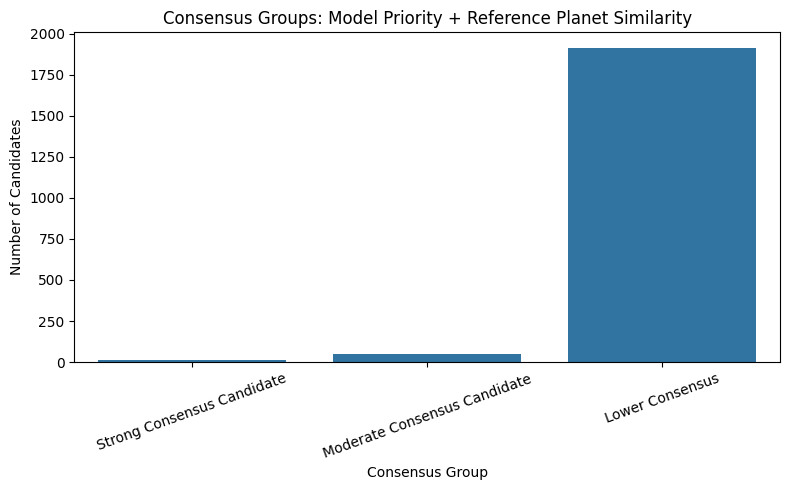

In [82]:
# Plot consensus groups

plt.figure(figsize=(8, 5))

sns.countplot(data=candidate_reference_similarity, x='consensus_group', order=consensus_order)

plt.title('Consensus Groups: Model Priority + Reference Planet Similarity')
plt.xlabel('Consensus Group')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Interpretation**

The strongest candidates are the ones that appear important in two different ways:

- the supervised model gives them high `planet_probability`;
- their physical features are close to the selected reference planets from the video.

This consensus step is useful for storytelling because the final shortlist is not based on only one score.

However, these are still **prioritized candidates**, not officially confirmed planets and not confirmed habitable planets.


<a id="bookmark-scientific-priority-score"></a>

## Scientific Priority Score

The model probability is useful, but scientific interest may also depend on physical properties.

Here I create a simple scientific priority score that rewards:

- high predicted planet probability,
- stronger transit signal-to-noise ratio,
- smaller estimated planet radius.

This score is a custom heuristic, not an official astronomical validation metric.


In [83]:
# Scientific priority score
# Higher probability, smaller radius, and stronger signal are rewarded.

candidate_df['scientific_priority_score'] = (
    candidate_df['planet_probability'] * 0.6
    + (candidate_df['koi_model_snr'] / candidate_df['koi_model_snr'].max()) * 0.2
    + (1 / (1 + candidate_df['koi_prad'])) * 0.2
)

scientific_ranking = (
    candidate_df[
        [
            'kepoi_name',
            'planet_probability',
            'scientific_priority_score',
            'priority_group',
            'koi_period',
            'koi_prad',
            'koi_teq',
            'koi_model_snr'
        ]
    ]
    .sort_values(by='scientific_priority_score', ascending=False)
)

scientific_ranking.head(15)


,kepoi_name,planet_probability,scientific_priority_score,priority_group,koi_period,koi_prad,koi_teq,koi_model_snr
8960,K04032.05,0.936667,0.673998,High Priority,7.235242,0.82,948.0,15.2
4379,K04452.01,0.960000,0.667656,High Priority,12.857559,1.23,860.0,14.2
1920,K02159.01,0.956667,0.663605,High Priority,7.596700,1.32,964.0,24.5
537,K01145.01,0.993333,0.660832,High Priority,30.587215,2.32,621.0,33.1
304,K00935.04,0.976667,0.656552,High Priority,9.617314,1.94,1010.0,18.2
7277,K01628.03,0.966667,0.655751,High Priority,37.840423,1.76,607.0,23.7
744,K01315.01,0.966667,0.654001,High Priority,6.846399,1.90,1132.0,36.3
2793,K03119.01,0.913333,0.653825,High Priority,2.184438,0.94,529.0,19.7
2213,K02531.01,0.970000,0.652314,High Priority,17.699739,1.96,523.0,19.8
2906,K02984.01,0.923333,0.650531,High Priority,11.455419,1.12,975.0,15.8


<a id="bookmark-ranking-stability"></a>

## Ranking Stability

Because the priority score is a custom heuristic and not an official astronomical metric, I test different weighting scenarios.

In all scenarios, the model's predicted planet probability receives the largest weight, because it is the main output of the trained classifier. Signal-to-noise ratio and planet radius are used only as supporting scientific filters.

If the same candidates remain near the top across different weighting choices, the ranking is more robust. If the ranking changes strongly, the score should be interpreted with more caution.


In [84]:
candidate_df['score_60_20_20'] = (
    candidate_df['planet_probability'] * 0.60
    + (candidate_df['koi_model_snr'] / candidate_df['koi_model_snr'].max()) * 0.20
    + (1 / (1 + candidate_df['koi_prad'])) * 0.20
)

candidate_df['score_70_15_15'] = (
    candidate_df['planet_probability'] * 0.70
    + (candidate_df['koi_model_snr'] / candidate_df['koi_model_snr'].max()) * 0.15
    + (1 / (1 + candidate_df['koi_prad'])) * 0.15
)

candidate_df['score_80_10_10'] = (
    candidate_df['planet_probability'] * 0.80
    + (candidate_df['koi_model_snr'] / candidate_df['koi_model_snr'].max()) * 0.10
    + (1 / (1 + candidate_df['koi_prad'])) * 0.10
)

In [85]:
candidate_df[['kepoi_name', 'planet_probability', 'koi_model_snr', 'koi_prad', 'score_60_20_20']].sort_values(by='score_60_20_20', ascending=False).head(10)

,kepoi_name,planet_probability,koi_model_snr,koi_prad,score_60_20_20
8960,K04032.05,0.936667,15.2,0.82,0.673998
4379,K04452.01,0.960000,14.2,1.23,0.667656
1920,K02159.01,0.956667,24.5,1.32,0.663605
537,K01145.01,0.993333,33.1,2.32,0.660832
304,K00935.04,0.976667,18.2,1.94,0.656552
7277,K01628.03,0.966667,23.7,1.76,0.655751
744,K01315.01,0.966667,36.3,1.90,0.654001
2793,K03119.01,0.913333,19.7,0.94,0.653825
2213,K02531.01,0.970000,19.8,1.96,0.652314
2906,K02984.01,0.923333,15.8,1.12,0.650531


In [86]:
candidate_df[['kepoi_name', 'planet_probability', 'koi_model_snr', 'koi_prad', 'score_70_15_15']].sort_values(by='score_70_15_15', ascending=False).head(10)

,kepoi_name,planet_probability,koi_model_snr,koi_prad,score_70_15_15
537,K01145.01,0.993333,33.1,2.32,0.743957
4379,K04452.01,0.960000,14.2,1.23,0.740742
8960,K04032.05,0.936667,15.2,0.82,0.739665
1920,K02159.01,0.956667,24.5,1.32,0.736871
304,K00935.04,0.976667,18.2,1.94,0.736580
7277,K01628.03,0.966667,23.7,1.76,0.733480
1404,K01972.01,0.986667,39.8,2.88,0.733467
7238,K01053.02,0.983333,15.5,2.46,0.733298
3436,K00641.01,0.980000,58.3,2.73,0.732279
744,K01315.01,0.966667,36.3,1.90,0.732167


In [87]:
candidate_df[
    ['kepoi_name', 'planet_probability', 'koi_model_snr', 'koi_prad', 'score_80_10_10']
].sort_values(by='score_80_10_10', ascending=False).head(10)

,kepoi_name,planet_probability,koi_model_snr,koi_prad,score_80_10_10
537,K01145.01,0.993333,33.1,2.32,0.827083
1404,K01972.01,0.986667,39.8,2.88,0.817867
7238,K01053.02,0.983333,15.5,2.46,0.816643
304,K00935.04,0.976667,18.2,1.94,0.816609
3436,K00641.01,0.980000,58.3,2.73,0.814853
4424,K04526.01,0.983333,15.0,2.72,0.814589
1535,K01861.01,0.986667,47.5,3.56,0.814557
3027,K00426.01,0.986667,62.4,3.84,0.814322
4379,K04452.01,0.960000,14.2,1.23,0.813828
7277,K01628.03,0.966667,23.7,1.76,0.811209


In [88]:
#Ranking stability under different scientific priority weights

score_scenarios = {
    '60/20/20': 'score_60_20_20',
    '70/15/15': 'score_70_15_15',
    '80/10/10': 'score_80_10_10'
}

top_n = 10
rank_tables = []

for scenario_name, score_col in score_scenarios.items():
    temp = candidate_df[['kepoi_name', score_col]].sort_values(by=score_col, ascending=False).head(top_n).copy()

    temp['scenario'] = scenario_name
    temp['rank'] = range(1, len(temp) + 1)
    rank_tables.append(temp[['kepoi_name', 'scenario', 'rank']])

ranking_stability_df = pd.concat(rank_tables)

ranking_stability_pivot = ranking_stability_df.pivot(index='kepoi_name', columns='scenario', values='rank')

ranking_stability_pivot

scenario,60/20/20,70/15/15,80/10/10
kepoi_name,,,
K00426.01,NaN,NaN,8.0
K00641.01,NaN,9.0,5.0
K00935.04,5.0,5.0,4.0
K01053.02,NaN,8.0,3.0
K01145.01,4.0,1.0,1.0
K01315.01,7.0,10.0,NaN
K01628.03,6.0,6.0,10.0
K01861.01,NaN,NaN,7.0
K01972.01,NaN,7.0,2.0


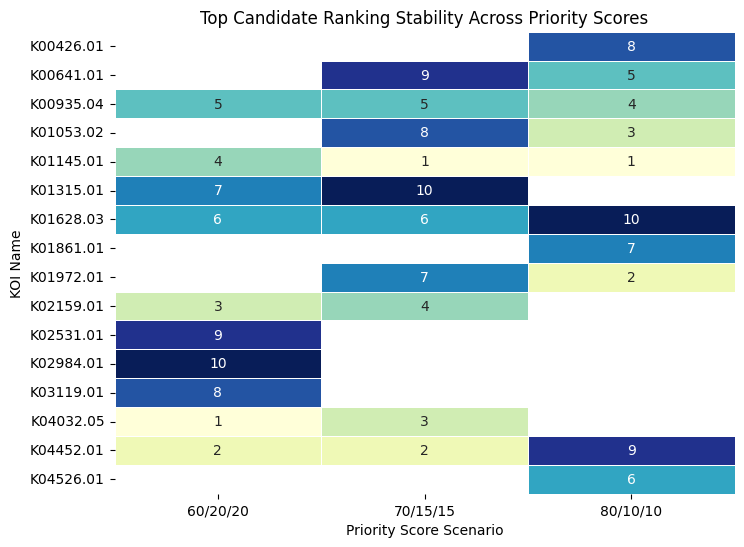

In [89]:
#Heatmap of top-candidate rank stability

plt.figure(figsize=(8, 6))
sns.heatmap(ranking_stability_pivot, annot=True, cmap='YlGnBu', cbar=False, linewidths=0.5)

plt.title('Top Candidate Ranking Stability Across Priority Scores')
plt.xlabel('Priority Score Scenario')
plt.ylabel('KOI Name')
plt.show()

In [90]:
# Extract useful values for final findings

best_result = final_results_df[final_results_df['Model'] == best_model_name].iloc[0]

best_model = best_model_name
best_f1_macro = best_result['F1 Macro']
best_roc_auc = best_result['ROC_AUC']
best_recall_macro = best_result['Recall Macro']
best_precision_macro = best_result['Precision Macro']

top_features = perm_importance_df.head(5)['feature'].tolist()
priority_counts = candidate_df['priority_group'].value_counts()

print("Best model:", best_model)
print("Macro F1 Score:", best_f1_macro)
print("ROC-AUC:", best_roc_auc)
print("Top features:", top_features)
print("\nPriority groups:")
print(priority_counts)


Best model: Random Forest
Macro F1 Score: 0.9288302277432712
ROC-AUC: 0.978365890308039
Top features: ['koi_prad', 'koi_impact', 'koi_model_snr', 'koi_duration', 'koi_period']

Priority groups:
priority_group
Low Priority       1706
Medium Priority     214
High Priority        58
Name: count, dtype: int64


<a id="bookmark-final-results"></a>

# Final Results and Findings

## Main Project Result

This project developed an interpretable machine-learning pipeline for prioritizing unresolved Kepler exoplanet candidates.

The goal was not only to train a classifier, but to build a scientific decision-support system that can rank candidate objects based on their probability of being planet-like and their physical properties.

## Model Performance

Several models were compared, including Logistic Regression, Random Forest, Gradient Boosting, and Support Vector Machine.

The final model was selected based on macro F1-score and ROC-AUC. These metrics are more useful than accuracy alone because macro F1-score treats both classes equally, while ROC-AUC evaluates probability-based separation for candidate ranking.

Cross-validation was also used to check whether model performance was stable across different data splits.

## Scientific Interpretation

Feature-importance analysis showed that the model relied strongly on transit-related and physical features such as planet radius, impact parameter, signal-to-noise ratio, transit duration, and orbital period.

This is scientifically meaningful because these features describe the shape, strength, and physical interpretation of transit signals.

## Candidate Prioritization

After training and evaluating the model, I applied it to unresolved Kepler candidates.

Each candidate received a predicted planet-like probability. Then I grouped candidates into High, Medium, and Low Priority groups.

I also created a scientific priority score that combines model probability, signal strength, and smaller planet radius. This score is not an official astronomical metric, but it helps identify candidates that may be interesting for follow-up study.

I added a reference-planet similarity check using known interesting Kepler planets. This compares unresolved candidates with reference planets using selected physical and habitability-related features. This does not prove habitability, but it adds another scientific-interest view to the ranking.

I also created a consensus-candidate section that intersects supervised model priority with reference-planet similarity. These candidates are more interesting because they are supported by two different ranking ideas: model probability and physical similarity to selected reference planets.


## Robustness Check

Because the scientific priority score depends on chosen weights, I tested different weighting scenarios. This helped check whether the top-ranked candidates remained stable.

Stable top candidates are more interesting because their ranking does not depend strongly on one arbitrary scoring choice.

## Main Limitation

This project does not officially confirm exoplanets.

The model uses tabular Kepler Object of Interest features, not raw light curves or full astrophysical validation methods. Therefore, the output should be interpreted as candidate prioritization, not official planet confirmation.

## Final Conclusion

The project shows how machine learning can support astronomical candidate selection by combining classification, probability ranking, feature interpretation, and scientific prioritization.

This makes the project more than a simple model-training exercise. It becomes a complete workflow for helping decide which unresolved Kepler candidates may deserve further scientific investigation.


<a id="bookmark-future-work"></a>

# Future Work

With more time, this project could be extended in several ways:

1. **Light curve analysis**  
   Instead of using only table features, future work could analyze raw Kepler light curves directly. This may allow the model to learn the shape and quality of transit signals.

2. **External validation**  
   The model could be tested on newer exoplanet datasets or compared with confirmed discoveries from other missions such as TESS.

3. **Habitable-zone analysis**  
   Candidate prioritization could include more detailed habitability-related features, such as stellar luminosity, planet radius, equilibrium temperature, and orbital distance.


4. **Model explainability**  
   More advanced explanation methods, such as SHAP values, could be used to understand how each feature affects individual predictions.